# Price Elasticity of Liquor Demand in Iowa
## Demand Analytics — Final Project

---

## Research Questions

> **Main:** How sensitive is liquor demand to price changes across counties and product categories in Iowa?
>
> **Secondary:** Do holidays and weekends amplify or weaken that price sensitivity, and does the effect persist dynamically?

This notebook frames the problem as a **demand modeling problem** — demand is a function of price, market characteristics, and time structure. We estimate price elasticities using a log-log regression framework with high-dimensional fixed effects, and validate predictions on a held-out time period.

---

## Model Roadmap

| Group | Models | Core Question |
|---|---|---|
| Functional Form | M0 Linear, M1 Semi-log, M2 Log-log ⭐, M3 Quadratic | What shape best describes price-demand? |
| Heterogeneity (Broad) | M4 Category (8 types), M5 Urban/Rural, M6 Cat × Market | Who is price sensitive? |
| Heterogeneity (Granular) | M4b Granular categories, M5b County-level, M5c County × Category heatmap | Where exactly are pricing levers strongest? |
| Calendar | M7 Holiday Interaction, M8 Month × Price, M9 Year Trend | When does sensitivity change? |
| Dynamic | M10 Lagged Demand, M11 Lagged Price | Does past demand/price predict today? |
| Cross-Price | M12 Vodka ↔ Whiskey | Are spirits substitutes? |
| Validation | Holdout 2016–2017 | How well does the model predict out of sample? |

---
# 1. Setup

Install dependencies:
```
pip install pyfixest pandas numpy matplotlib seaborn statsmodels linearmodels scikit-learn
```

We use **`pyfixest`** as the primary modeling package for panel fixed-effects models (Python equivalent of R's `fixest`), and **`statsmodels`** for granular OLS models and holdout validation.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
import re
import pyfixest as pf
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

# ── Presentation palette ─────────────────────────────────────────────────────
BG          = '#1F1009'
GOLD_BRIGHT = '#D4AF37'
GOLD_MID    = '#C9A227'
GOLD_WARM   = '#A67C3A'
GOLD_DARK   = '#7A4F2A'
TEXT_CREAM  = '#D8C3A5'
TEXT_DIM    = '#8A7055'
AXIS_COLOR  = '#4A3520'
PANEL_BG    = '#261408'

GOLD_CMAP = LinearSegmentedColormap.from_list(
    'gold_dark', [BG, GOLD_DARK, GOLD_WARM, GOLD_MID, GOLD_BRIGHT], N=256
)

def apply_dark_style(fig, axes_list=None):
    fig.patch.set_facecolor(BG)
    if axes_list is None:
        axes_list = fig.get_axes()
    for ax in axes_list:
        ax.set_facecolor(PANEL_BG)
        ax.tick_params(colors=TEXT_CREAM, labelcolor=TEXT_CREAM)
        ax.xaxis.label.set_color(TEXT_CREAM)
        ax.yaxis.label.set_color(TEXT_CREAM)
        ax.title.set_color(TEXT_CREAM)
        for spine in ax.spines.values():
            spine.set_edgecolor(AXIS_COLOR)
        ax.xaxis.set_tick_params(color=AXIS_COLOR)
        ax.yaxis.set_tick_params(color=AXIS_COLOR)
        ax.grid(True, color=AXIS_COLOR, alpha=0.4, linewidth=0.5)

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['figure.dpi'] = 110

DATA_PATH = 'cleaned_iowa_liquor_sales_merged.csv'
print('All packages loaded.')


All packages loaded.


In [43]:
import os
os.makedirs('figures', exist_ok=True)
print('figures/ directory ready.')

figures/ directory ready.


---
# 2. Data Loading & Preparation

The raw dataset contains **12.3 million** individual liquor transactions across 99 Iowa counties from 2012–2017.

In [3]:
print('Loading raw data... (this may take ~30 seconds for 12M rows)')

df = pd.read_csv(DATA_PATH, low_memory=False)

# Parse dollar-formatted columns
for col in ['State Bottle Cost', 'State Bottle Retail', 'Sale (Dollars)']:
    df[col] = df[col].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Date and time features
df['date']  = pd.to_datetime(df['Date'])
df['month'] = df['date'].dt.month
df['year']  = df['Year'].astype(int)
df['ym']    = df['date'].dt.to_period('M').astype(str)

# Weekend flag (Saturday=5, Sunday=6)
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# Price per liter at transaction level
df['price_per_liter'] = df['State Bottle Retail'] / (df['Bottle Volume (ml)'] / 1000)
df = df[(df['price_per_liter'] > 0) & np.isfinite(df['price_per_liter'])]

print(f'Rows after cleaning: {len(df):,}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Counties: {df["County"].nunique()} | Raw categories: {df["Category Name"].nunique()}')

Loading raw data... (this may take ~30 seconds for 12M rows)
Rows after cleaning: 12,297,359
Date range: 2012-01-03 to 2017-10-31
Counties: 99 | Raw categories: 130


## 2.1 Category Consolidation

The raw data has 130 granular category names. We consolidate into **8 broad spirit categories** for the main elasticity models. We preserve the granular categories for the deep-dive analysis in Section 7.

In [44]:
cat_map = {
    '100 PROOF VODKA': 'Vodka', 'VODKA 80 PROOF': 'Vodka',
    'VODKA FLAVORED': 'Vodka', 'IMPORTED VODKA': 'Vodka',
    'IMPORTED VODKA - MISC': 'Vodka', 'LOW PROOF VODKA': 'Vodka',
    'OTHER PROOF VODKA': 'Vodka',
    'BLENDED WHISKIES': 'Whiskey', 'CANADIAN WHISKIES': 'Whiskey',
    'IRISH WHISKIES': 'Whiskey', 'SCOTCH WHISKIES': 'Whiskey',
    'SINGLE MALT SCOTCH': 'Whiskey', 'STRAIGHT BOURBON WHISKIES': 'Whiskey',
    'STRAIGHT RYE WHISKIES': 'Whiskey', 'TENNESSEE WHISKIES': 'Whiskey',
    'BOTTLED IN BOND BOURBON': 'Whiskey',
    'SINGLE BARREL BOURBON WHISKIES': 'Whiskey',
    'WHISKEY LIQUEUR': 'Whiskey', 'ROCK & RYE': 'Whiskey',
    'BARBADOS RUM': 'Rum', 'FLAVORED RUM': 'Rum', 'JAMAICA RUM': 'Rum',
    'PUERTO RICO & VIRGIN ISLANDS RUM': 'Rum', 'SPICED RUM': 'Rum',
    'TEQUILA': 'Tequila',
    'AMERICAN DRY GINS': 'Gin', 'AMERICAN SLOE GINS': 'Gin',
    'FLAVORED GINS': 'Gin', 'IMPORTED DRY GINS': 'Gin',
    'AMERICAN GRAPE BRANDIES': 'Brandy', 'APRICOT BRANDIES': 'Brandy',
    'BLACKBERRY BRANDIES': 'Brandy', 'CHERRY BRANDIES': 'Brandy',
    'IMPORTED GRAPE BRANDIES': 'Brandy', 'MISCELLANEOUS BRANDIES': 'Brandy',
    'PEACH BRANDIES': 'Brandy',
    'APPLE SCHNAPPS': 'Schnapps', 'BUTTERSCOTCH SCHNAPPS': 'Schnapps',
    'CINNAMON SCHNAPPS': 'Schnapps', 'GRAPE SCHNAPPS': 'Schnapps',
    'IMPORTED SCHNAPPS': 'Schnapps', 'MISCELLANEOUS SCHNAPPS': 'Schnapps',
    'PEACH SCHNAPPS': 'Schnapps', 'PEPPERMINT SCHNAPPS': 'Schnapps',
    'RASPBERRY SCHNAPPS': 'Schnapps', 'ROOT BEER SCHNAPPS': 'Schnapps',
    'SPEARMINT SCHNAPPS': 'Schnapps', 'STRAWBERRY SCHNAPPS': 'Schnapps',
    'TROPICAL FRUIT SCHNAPPS': 'Schnapps', 'WATERMELON SCHNAPPS': 'Schnapps',
    'AMERICAN AMARETTO': 'Liqueurs', 'AMERICAN COCKTAILS': 'Liqueurs',
    'ANISETTE': 'Liqueurs', 'COFFEE LIQUEURS': 'Liqueurs',
    'CREAM LIQUEURS': 'Liqueurs', 'CREME DE ALMOND': 'Liqueurs',
    'DARK CREME DE CACAO': 'Liqueurs', 'GREEN CREME DE MENTHE': 'Liqueurs',
    'IMPORTED AMARETTO': 'Liqueurs',
    'MISC. AMERICAN CORDIALS & LIQUEURS': 'Liqueurs',
    'MISC. IMPORTED CORDIALS & LIQUEURS': 'Liqueurs',
    'TRIPLE SEC': 'Liqueurs', 'WHITE CREME DE CACAO': 'Liqueurs',
    'WHITE CREME DE MENTHE': 'Liqueurs',
    'AMERICAN ALCOHOL': 'Other', 'DECANTERS & SPECIALTY PACKAGES': 'Other',
    'DISTILLED SPIRITS SPECIALTY': 'Other',
}

df['category'] = df['Category Name'].map(cat_map)
print(f'Rows after category mapping: {len(df[df["category"].notna()]):,}')
print(f'Categories: {sorted(df["category"].dropna().unique())}')

Rows after category mapping: 9,786,815
Categories: ['Brandy', 'Gin', 'Liqueurs', 'Other', 'Rum', 'Schnapps', 'Tequila', 'Vodka', 'Whiskey']


## 2.2 Aggregate to Panel

**Unit of analysis:** county × year-month × category.

We build two panel datasets:
- **`panel`** — 8-category consolidation (main fixed-effects models)
- **`agg`** — granular 130 categories (deep-dive analysis in Section 7)

**Why liters per adult?** Normalizing by adult population (age 20+) makes cross-county comparisons fair.

In [45]:
# Holiday/weekend days per month
holiday_per_month = (
    df[df['Is_Holiday_Weekend'] == 1]
    .groupby('ym')['date']
    .nunique()
    .reset_index(name='holiday_days')
)

# PANEL A: 8-category consolidated (main fixed-effects models)
df_cat = df.dropna(subset=['category'])

panel = (
    df_cat.groupby(['County', 'ym', 'category', 'year', 'month'])
    .agg(
        total_liters  = ('Volume Sold (Liters)', 'sum'),
        total_bottles = ('Bottles Sold', 'sum'),
        total_sales   = ('Sale (Dollars)', 'sum'),
        population    = ('Population', 'first'),
        weekend_count = ('is_weekend', 'sum'),
    )
    .reset_index()
)
panel['avg_price_liter'] = panel['total_sales'] / panel['total_liters']
panel = panel.merge(holiday_per_month, on='ym', how='left')
panel['holiday_days']     = panel['holiday_days'].fillna(0)
panel['liters_per_adult'] = panel['total_liters'] / panel['population']
panel = panel[(panel['liters_per_adult'] > 0) & (panel['avg_price_liter'] > 0)]
panel['log_liters_pa'] = np.log(panel['liters_per_adult'])
panel['log_price']     = np.log(panel['avg_price_liter'])
panel['log_price_sq']  = panel['log_price'] ** 2
panel['market_type']   = pd.cut(
    panel['population'],
    bins=[0, 20_000, 100_000, np.inf],
    labels=['Rural', 'Micropolitan', 'Metro']
).astype(str)
panel = panel.rename(columns={'County': 'county'})
panel = panel.sort_values(['county', 'category', 'ym']).reset_index(drop=True)
panel['log_liters_pa_lag'] = panel.groupby(['county', 'category'])['log_liters_pa'].shift(1)
panel['log_price_lag']     = panel.groupby(['county', 'category'])['log_price'].shift(1)
panel['year_c']    = panel['year'] - 2014
panel['month_str'] = panel['month'].astype(str).str.zfill(2)

# PANEL B: Granular 130-category (deep-dive analysis)
agg = (
    df.groupby(['County', 'year', 'month', 'Category Name'])
    .agg(
        Total_Liters  = ('Volume Sold (Liters)', 'sum'),
        Total_Sales   = ('Sale (Dollars)', 'sum'),
        Population    = ('Population', 'first'),
        Is_Holiday    = ('Is_Holiday_Weekend', 'max'),
        Holiday_Days  = ('Is_Holiday_Weekend', 'sum'),
        Weekend_Count = ('is_weekend', 'sum'),
    )
    .reset_index()
)
agg = agg.rename(columns={'year': 'Year', 'month': 'Month'})
agg['Demand']     = agg['Total_Liters'] / agg['Population']
agg['Avg_Price']  = agg['Total_Sales'] / agg['Total_Liters']
agg['log_demand'] = np.log(agg['Demand'].replace(0, np.nan))
agg['log_price']  = np.log(agg['Avg_Price'].replace(0, np.nan))
agg = agg.dropna(subset=['log_demand', 'log_price'])

print(f'Panel (8-cat): {panel.shape}')
print(f'  {panel["county"].nunique()} counties | {panel["category"].nunique()} categories | {panel["ym"].nunique()} year-months')
print(f'Agg (granular): {agg.shape}')
print(f'  {agg["County"].nunique()} counties | {agg["Category Name"].nunique()} categories')
print(f'Obs with lag: {panel["log_liters_pa_lag"].notna().sum():,}')

Panel (8-cat): (49238, 21)
  99 counties | 9 categories | 56 year-months
Agg (granular): (324410, 14)
  99 counties | 130 categories
Obs with lag: 48,347


---
# 3. Exploratory Data Analysis

## 3A. Price and Demand Distributions

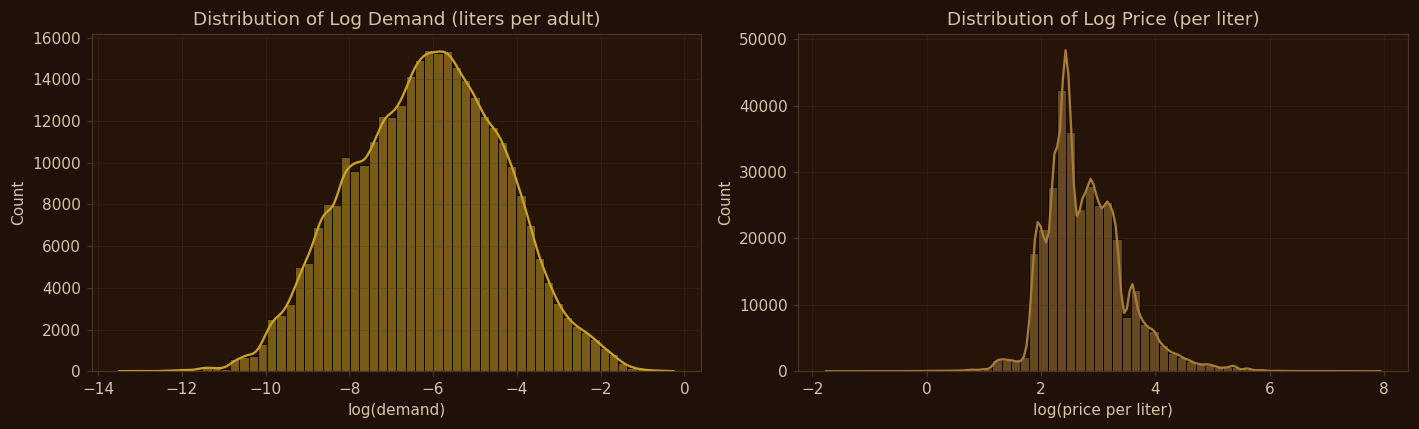

Takeaway: Both variables are approximately log-normal, validating the log-log functional form.


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
apply_dark_style(fig, axes)
sns.histplot(agg['log_demand'], bins=60, kde=True, ax=axes[0],
             color=GOLD_MID, line_kws={'color': GOLD_BRIGHT, 'lw': 1.5})
axes[0].set_title('Distribution of Log Demand (liters per adult)', color=TEXT_CREAM)
axes[0].set_xlabel('log(demand)', color=TEXT_CREAM)
axes[0].set_ylabel('Count', color=TEXT_CREAM)
sns.histplot(agg['log_price'], bins=60, kde=True, ax=axes[1],
             color=GOLD_WARM, line_kws={'color': GOLD_BRIGHT, 'lw': 1.5})
axes[1].set_title('Distribution of Log Price (per liter)', color=TEXT_CREAM)
axes[1].set_xlabel('log(price per liter)', color=TEXT_CREAM)
axes[1].set_ylabel('Count', color=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/3A_demand_price_distributions.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()
print('Takeaway: Both variables are approximately log-normal, validating the log-log functional form.')


## 3B. Raw Log-Log Scatter

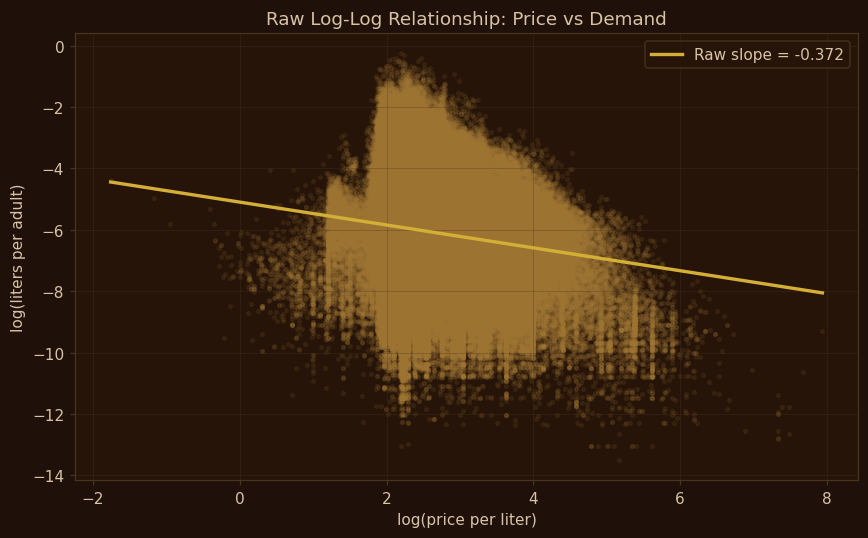

Raw (unadjusted) elasticity: -0.372
Note: Fixed effects absorb confounds like county wealth — within-unit elasticity will differ.


In [47]:
fig, ax = plt.subplots(figsize=(8, 5))
apply_dark_style(fig, [ax])
ax.scatter(agg['log_price'], agg['log_demand'], alpha=0.10, s=6, color=GOLD_WARM)
m, b = np.polyfit(agg['log_price'], agg['log_demand'], 1)
x_range = np.linspace(agg['log_price'].min(), agg['log_price'].max(), 100)
ax.plot(x_range, m * x_range + b, color=GOLD_BRIGHT, linewidth=2.2, label=f'Raw slope = {m:.3f}')
ax.set_xlabel('log(price per liter)', color=TEXT_CREAM)
ax.set_ylabel('log(liters per adult)', color=TEXT_CREAM)
ax.set_title('Raw Log-Log Relationship: Price vs Demand', color=TEXT_CREAM)
ax.legend(facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/3B_raw_loglog_scatter.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()
print(f'Raw (unadjusted) elasticity: {m:.3f}')
print('Note: Fixed effects absorb confounds like county wealth — within-unit elasticity will differ.')


## 3C. Monthly Sales Trends by Category

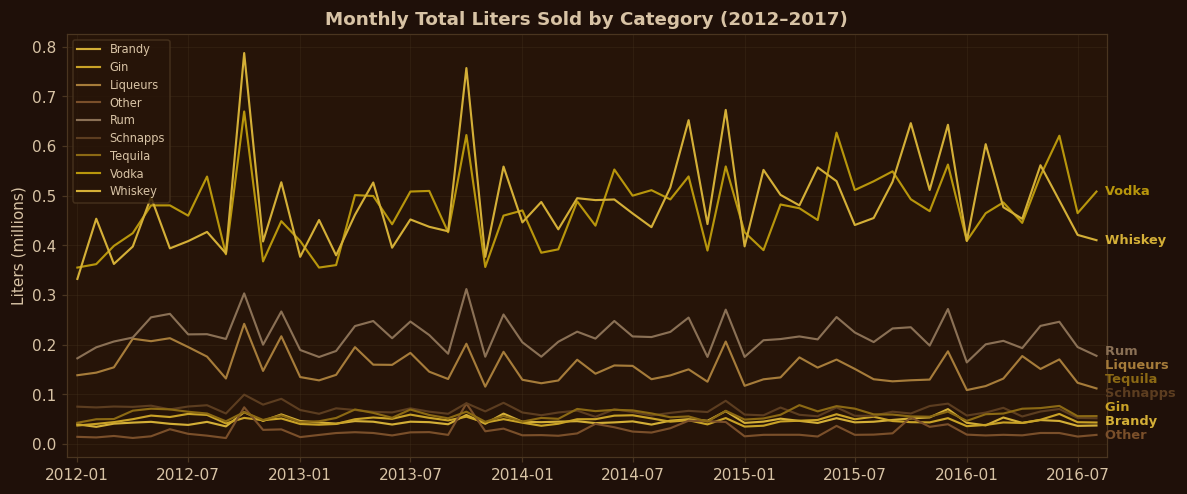

Takeaway: Vodka and Whiskey dominate volume. Year-end spikes confirm seasonal controls are essential.


In [76]:
monthly = panel.groupby(['ym', 'category'])['total_liters'].sum().reset_index()
monthly['date'] = pd.to_datetime(monthly['ym'])
line_colors = [GOLD_BRIGHT, GOLD_MID, GOLD_WARM, GOLD_DARK, TEXT_DIM,
               '#5C3D20', '#8B6914', '#B8960C']

fig, ax = plt.subplots(figsize=(14, 5))
apply_dark_style(fig, [ax])

# Collect last-point y values for nudging
endpoints = []
for i, (cat, grp) in enumerate(monthly.groupby('category')):
    c = line_colors[i % len(line_colors)]
    grp = grp.sort_values('date')
    ax.plot(grp['date'], grp['total_liters'] / 1e6, label=cat, linewidth=1.4, color=c)
    last = grp.iloc[-1]
    endpoints.append({'cat': cat, 'date': last['date'], 'y': last['total_liters'] / 1e6, 'color': c})

# Sort by y and nudge overlapping labels (min gap = 0.028 M liters)
endpoints.sort(key=lambda x: x['y'])
MIN_GAP = 0.028
for j in range(1, len(endpoints)):
    if endpoints[j]['y'] - endpoints[j-1]['y'] < MIN_GAP:
        endpoints[j]['y'] = endpoints[j-1]['y'] + MIN_GAP

for ep in endpoints:
    ax.text(ep['date'], ep['y'], f"  {ep['cat']}",
            va='center', ha='left', fontsize=8.5, color=ep['color'], fontweight='bold')

ax.set_title('Monthly Total Liters Sold by Category (2012–2017)', fontweight='bold', color=TEXT_CREAM)
ax.set_ylabel('Liters (millions)', color=TEXT_CREAM)
ax.margins(x=0.01)
fig.subplots_adjust(right=0.80)
ax.legend(loc='upper left', fontsize=7.5, ncol=1,
          facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.savefig('figures/3C_monthly_sales_by_category.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()
print('Takeaway: Vodka and Whiskey dominate volume. Year-end spikes confirm seasonal controls are essential.')


## 3D. Seasonality Heatmap — Avg Log Demand by Month x Category

Reveals which categories have the strongest seasonal patterns.

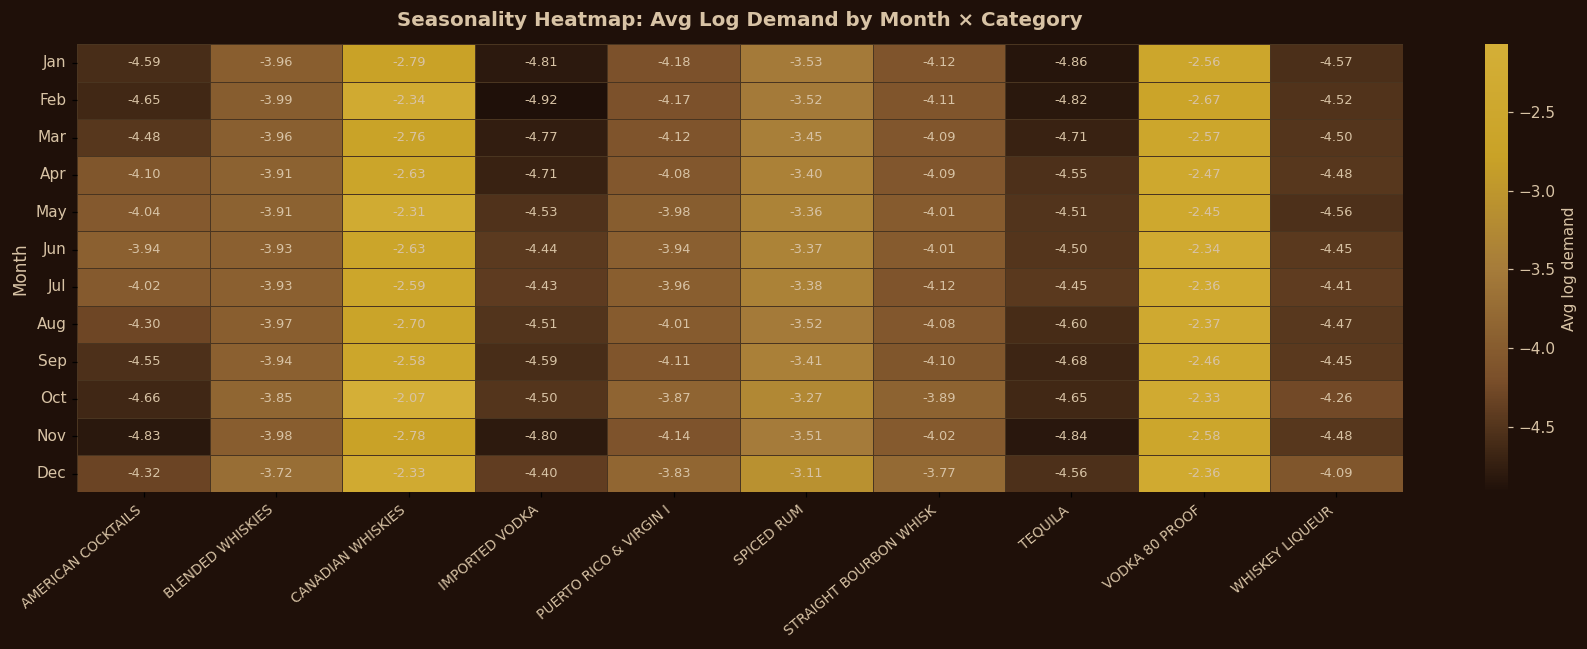

In [49]:
top10_cats = agg.groupby('Category Name')['Total_Liters'].sum().nlargest(10).index
heat_data  = (
    agg[agg['Category Name'].isin(top10_cats)]
    .groupby(['Month', 'Category Name'])['log_demand']
    .mean().unstack('Category Name')
)
heat_data.columns = [c[:22] for c in heat_data.columns]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL_BG)
sns.heatmap(heat_data, cmap=GOLD_CMAP, annot=True, fmt='.2f',
            annot_kws={'size': 8.5, 'color': TEXT_CREAM},
            linewidths=0.4, linecolor=AXIS_COLOR, ax=ax,
            cbar_kws={'label': 'Avg log demand'})
cbar = ax.collections[0].colorbar
cbar.set_label('Avg log demand', color=TEXT_CREAM)
cbar.ax.yaxis.set_tick_params(color=TEXT_CREAM, labelcolor=TEXT_CREAM)
ax.set_yticklabels(month_labels[:len(heat_data)], rotation=0, fontsize=10, color=TEXT_CREAM)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9, color=TEXT_CREAM)
ax.set_xlabel('', color=TEXT_CREAM)
ax.set_ylabel('Month', fontsize=11, color=TEXT_CREAM)
ax.set_title('Seasonality Heatmap: Avg Log Demand by Month × Category',
             fontsize=13, fontweight='bold', color=TEXT_CREAM, pad=12)
for spine in ax.spines.values():
    spine.set_edgecolor(AXIS_COLOR)
plt.tight_layout()
plt.savefig('figures/3D_seasonality_heatmap.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


## 3E. Price Distribution by Category

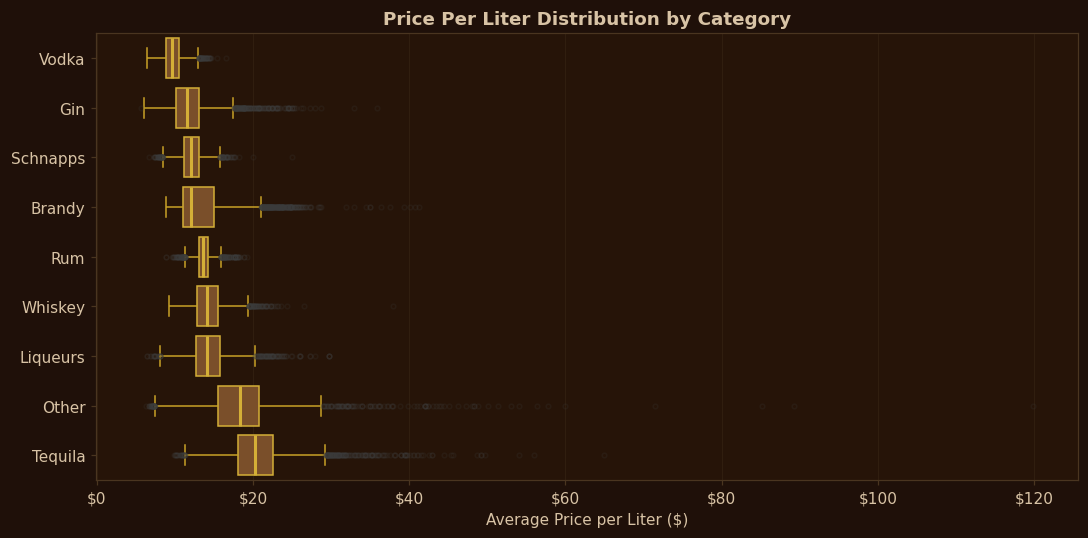

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
apply_dark_style(fig, [ax])
order = panel.groupby('category')['avg_price_liter'].median().sort_values().index
sns.boxplot(data=panel, y='category', x='avg_price_liter', order=order,
            flierprops=dict(marker='.', alpha=0.2, color=TEXT_DIM), ax=ax,
            boxprops=dict(facecolor=GOLD_DARK, edgecolor=GOLD_BRIGHT),
            whiskerprops=dict(color=GOLD_MID), capprops=dict(color=GOLD_MID),
            medianprops=dict(color=GOLD_BRIGHT, linewidth=2))
ax.set_title('Price Per Liter Distribution by Category', fontweight='bold', color=TEXT_CREAM)
ax.set_xlabel('Average Price per Liter ($)', color=TEXT_CREAM)
ax.set_ylabel('', color=TEXT_CREAM)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.savefig('figures/3E_price_distribution_by_category.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


## 3F. Per-Adult Demand by Market Type

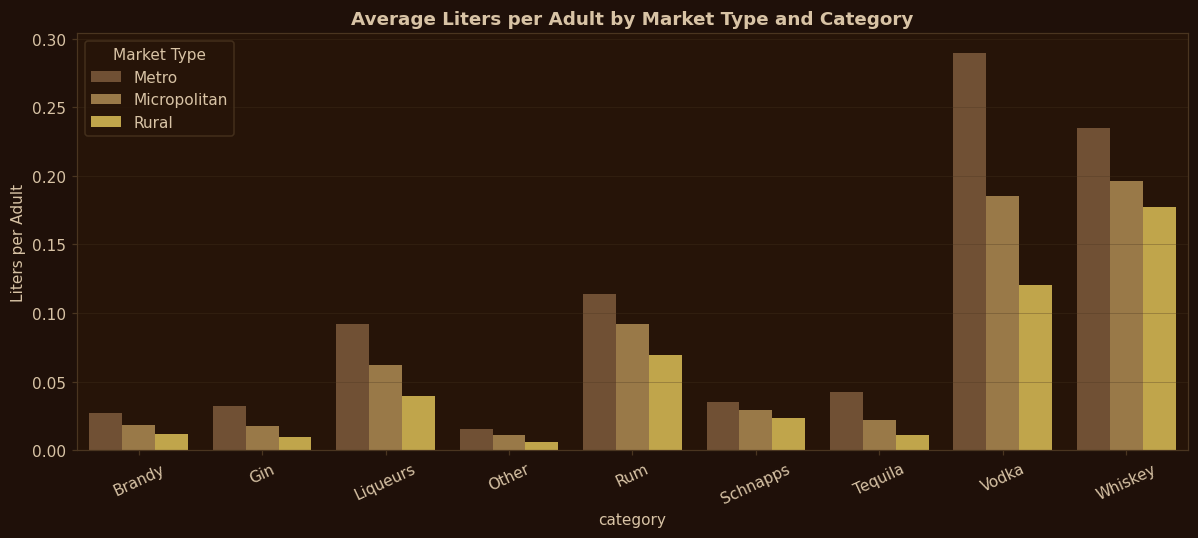

Takeaway: Per-adult demand differs systematically by market type. Motivates M5 heterogeneity models.


In [51]:
market_demand = panel.groupby(['market_type', 'category'])['liters_per_adult'].mean().reset_index()
fig, ax = plt.subplots(figsize=(11, 5))
apply_dark_style(fig, [ax])
sns.barplot(data=market_demand, x='category', y='liters_per_adult', hue='market_type',
            palette={'Rural': GOLD_BRIGHT, 'Micropolitan': GOLD_WARM, 'Metro': GOLD_DARK}, ax=ax)
ax.set_title('Average Liters per Adult by Market Type and Category', fontweight='bold', color=TEXT_CREAM)
ax.set_ylabel('Liters per Adult', color=TEXT_CREAM)
ax.tick_params(axis='x', rotation=25, labelcolor=TEXT_CREAM)
leg = ax.legend(title='Market Type', facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
leg.get_title().set_color(TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/3F_demand_by_market_type.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()
print('Takeaway: Per-adult demand differs systematically by market type. Motivates M5 heterogeneity models.')


## 3G. Holiday vs Non-Holiday Demand

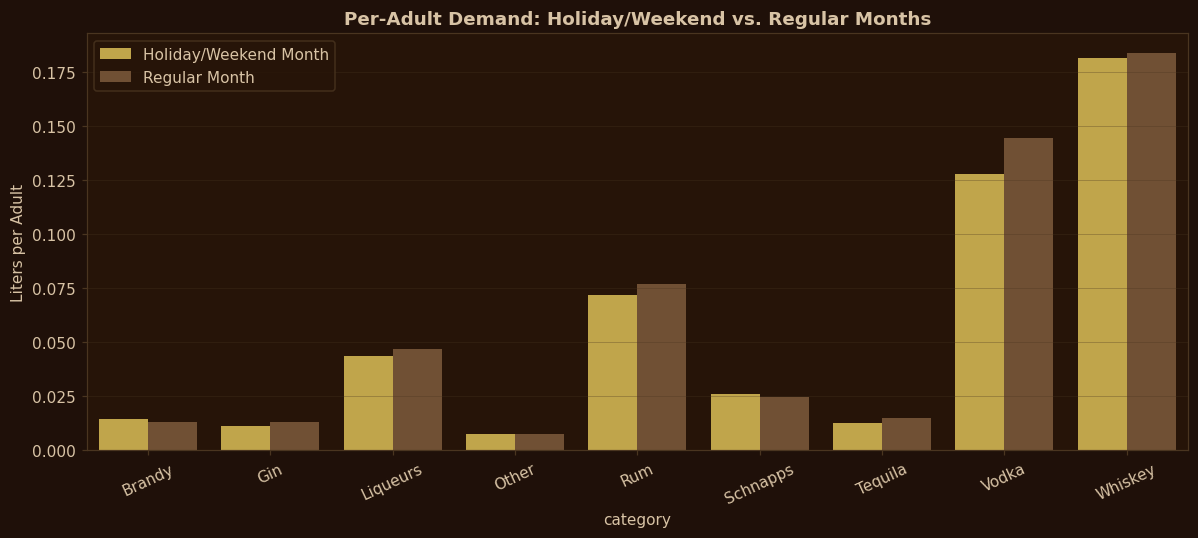

In [52]:
panel['holiday_flag'] = np.where(panel['holiday_days'] > 0, 'Holiday/Weekend Month', 'Regular Month')
hol_demand = panel.groupby(['holiday_flag', 'category'])['liters_per_adult'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
apply_dark_style(fig, [ax])
sns.barplot(data=hol_demand, x='category', y='liters_per_adult', hue='holiday_flag',
            palette={'Regular Month': GOLD_DARK, 'Holiday/Weekend Month': GOLD_BRIGHT}, ax=ax)
ax.set_title('Per-Adult Demand: Holiday/Weekend vs. Regular Months', fontweight='bold', color=TEXT_CREAM)
ax.set_ylabel('Liters per Adult', color=TEXT_CREAM)
ax.tick_params(axis='x', rotation=25, labelcolor=TEXT_CREAM)
leg = ax.legend(title='', facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/3G_holiday_vs_nonholiday_demand.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


## 3H. Faceted Price vs Demand by Top Category

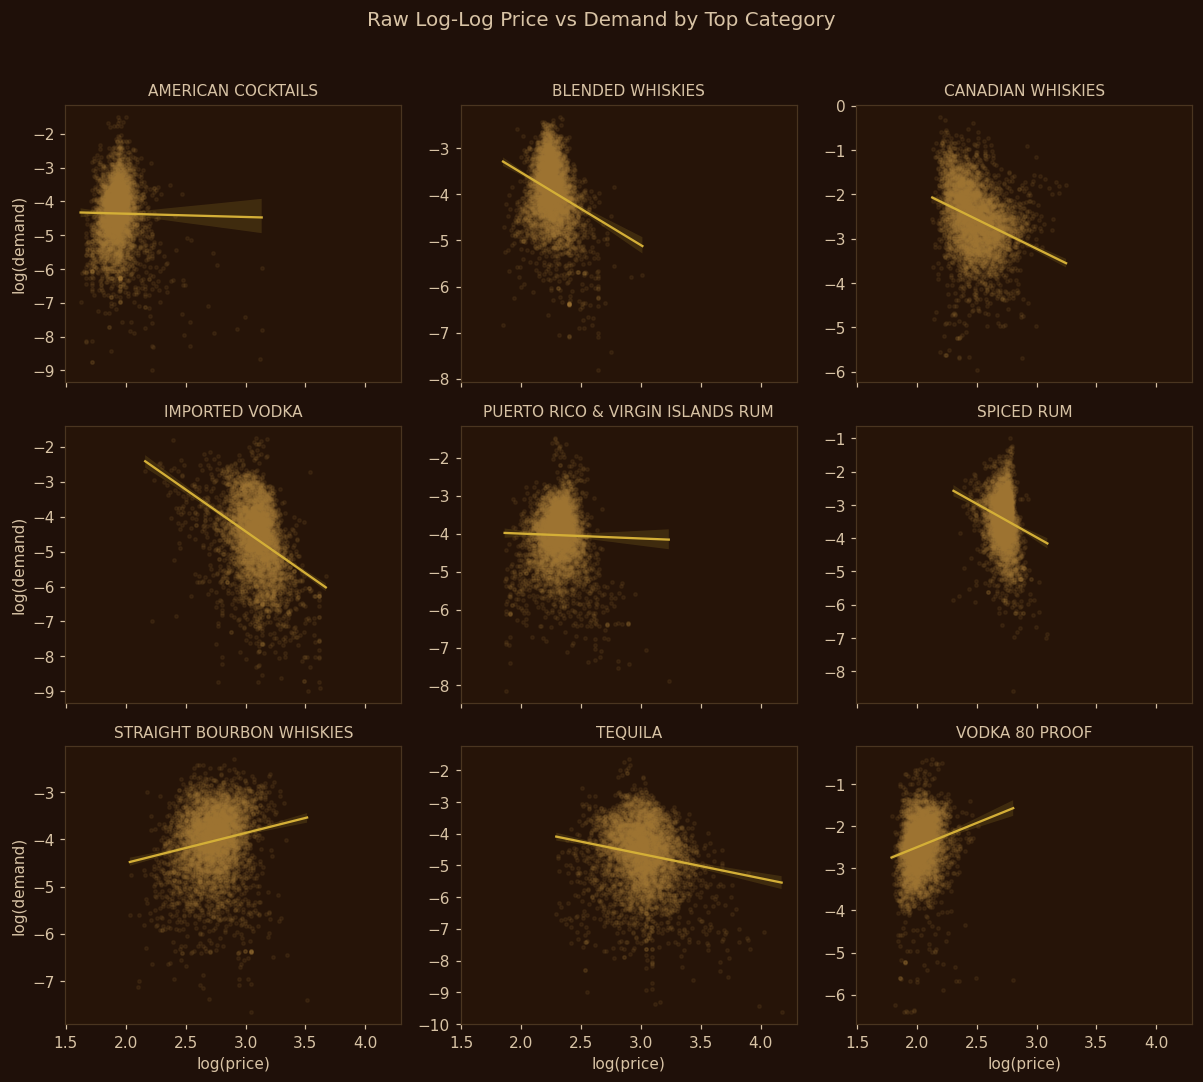

In [53]:
top9 = agg.groupby('Category Name')['Total_Liters'].sum().nlargest(9).index.tolist()
sub9 = agg[agg['Category Name'].isin(top9)].copy()

with plt.rc_context({'figure.facecolor': BG, 'axes.facecolor': PANEL_BG,
                     'axes.edgecolor': AXIS_COLOR, 'axes.labelcolor': TEXT_CREAM,
                     'xtick.color': TEXT_CREAM, 'ytick.color': TEXT_CREAM,
                     'text.color': TEXT_CREAM, 'grid.color': AXIS_COLOR}):
    g = sns.FacetGrid(sub9, col='Category Name', col_wrap=3, height=3.2, aspect=1.15,
                      sharey=False, despine=False)
    g.map_dataframe(sns.regplot, x='log_price', y='log_demand',
                    scatter_kws=dict(alpha=0.10, s=5, color=GOLD_WARM),
                    line_kws=dict(color=GOLD_BRIGHT, linewidth=1.5))
    g.set_titles(col_template='{col_name}')
    g.set_axis_labels('log(price)', 'log(demand)')
    g.figure.suptitle('Raw Log-Log Price vs Demand by Top Category', y=1.02, fontsize=13, color=TEXT_CREAM)
    g.figure.patch.set_facecolor(BG)
    for fa in g.axes.flat:
        fa.set_facecolor(PANEL_BG)
        for sp in fa.spines.values():
            sp.set_edgecolor(AXIS_COLOR)
        fa.tick_params(colors=TEXT_CREAM, labelcolor=TEXT_CREAM)
    plt.tight_layout()
    plt.savefig('figures/3H_loglog_scatter_by_top_category.png', bbox_inches='tight', dpi=150, facecolor=BG)
    plt.show()


---
# 4. Modeling Framework

## Why Log-Log?

In a **log-log** model, the coefficient on `log(price)` is directly interpretable as the **price elasticity of demand** — the % change in quantity for a 1% change in price.

## Fixed Effects Strategy

| Fixed Effect | What it controls for |
|---|---|
| County FE | Time-invariant county characteristics (demographics, income, culture) |
| Category FE | Permanent differences in demand level across spirit types |
| Month FE | Seasonal patterns common to all counties and categories |
| Year FE | Aggregate demand trends and macro shocks |

**`pyfixest` syntax:** `feols("y ~ x | fe1 + fe2 + fe3", data=df)` — variables after `|` are absorbed as fixed effects; standard errors clustered by county.

In [54]:
def show_results(model, title='', stars=True):
    """Print key model results excluding fixed effect intercepts."""
    tidy = model.tidy()
    tidy = tidy[tidy.index != 'Intercept']

    def sig(p):
        if p < 0.01: return '***'
        if p < 0.05: return '**'
        if p < 0.10: return '*'
        return ''

    if stars:
        tidy['stars'] = tidy['Pr(>|t|)'].apply(sig)

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(tidy[['Estimate', 'Std. Error', 'Pr(>|t|)', 'stars']].to_string())

    def _get(obj, *attrs, default='N/A'):
        for a in attrs:
            v = getattr(obj, a, None)
            if v is not None:
                return v
        return default

    n      = _get(model, '_N', 'N', 'nobs')
    r2     = _get(model, '_r2', 'r2')
    r2_adj = _get(model, '_r2_adj', 'adj_r2', 'r2_adj')

    n_str      = f'{int(n):,}'   if isinstance(n,      (int, float)) else str(n)
    r2_str     = f'{r2:.4f}'     if isinstance(r2,     (int, float)) else str(r2)
    r2_adj_str = f'{r2_adj:.4f}' if isinstance(r2_adj, (int, float)) else str(r2_adj)

    print(f"\n  N = {n_str}  |  R2 = {r2_str}  |  Adj. R2 = {r2_adj_str}")
    print(f"  Significance: * p<0.10  ** p<0.05  *** p<0.01")
    return tidy

---
# 5. Functional Form Models (M0 - M3)

These models test what **shape** best describes the price-demand relationship.

## M0 - Linear Baseline

Regresses raw `liters_per_adult` on price levels. Assumes a $1 increase always reduces demand by the same amount.

In [55]:
m0 = pf.feols(
    'liters_per_adult ~ avg_price_liter + holiday_days | county + category + month + year',
    data=panel, vcov={'CRV1': 'county'}
)
show_results(m0, 'M0: Linear Baseline (DV = liters_per_adult)')


  M0: Linear Baseline (DV = liters_per_adult)
                 Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                          
avg_price_liter    0.0000      0.0002    0.9781      
holiday_days      -0.0005      0.0003    0.1552      

  N = 49,238  |  R2 = 0.7273  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%,stars
Coefficient,,,,,,,
avg_price_liter,0.0000,0.0002,0.0275,0.9781,-0.0004,0.0004,
holiday_days,-0.0005,0.0003,-1.4323,0.1552,-0.0011,0.0002,


## M1 - Semi-Log

Logs the dependent variable but leaves price in levels.

In [56]:
m1 = pf.feols(
    'log_liters_pa ~ avg_price_liter + holiday_days | county + category + month + year',
    data=panel, vcov={'CRV1': 'county'}
)
show_results(m1, 'M1: Semi-Log (DV = log(liters_per_adult), Price in levels)')


  M1: Semi-Log (DV = log(liters_per_adult), Price in levels)
                 Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                          
avg_price_liter   -0.0287      0.0042    0.0000   ***
holiday_days      -0.0318      0.0062    0.0000   ***

  N = 49,238  |  R2 = 0.8699  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%,stars
Coefficient,,,,,,,
avg_price_liter,-0.0287,0.0042,-6.8576,0.0000,-0.0370,-0.0204,***
holiday_days,-0.0318,0.0062,-5.1008,0.0000,-0.0441,-0.0194,***


## M2 - Log-Log (Main Model)

Both demand and price are logged. The coefficient on `log_price` IS the price elasticity of demand.

In [57]:
m2 = pf.feols(
    'log_liters_pa ~ log_price + holiday_days | county + category + month + year',
    data=panel, vcov={'CRV1': 'county'}
)
show_results(m2, 'M2: Log-Log Baseline (Coefficient on log_price = Price Elasticity)')


  M2: Log-Log Baseline (Coefficient on log_price = Price Elasticity)
              Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                       
log_price      -0.4608      0.0639    0.0000   ***
holiday_days   -0.0323      0.0062    0.0000   ***

  N = 49,238  |  R2 = 0.8697  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%,stars
Coefficient,,,,,,,
log_price,-0.4608,0.0639,-7.2134,0.0000,-0.5875,-0.3340,***
holiday_days,-0.0323,0.0062,-5.1782,0.0000,-0.0447,-0.0199,***


## M3 - Quadratic Log-Log

Adds (log P)^2 to test whether elasticity changes at different price levels.

In [58]:
m3 = pf.feols(
    'log_liters_pa ~ log_price + log_price_sq + holiday_days | county + category + month + year',
    data=panel, vcov={'CRV1': 'county'}
)
show_results(m3, 'M3: Quadratic Log-Log (Tests Non-Constant Elasticity)')

b1 = m3.coef()['log_price']
b2 = m3.coef()['log_price_sq']
median_log_p = panel['log_price'].median()
print(f"\nImplied elasticity at median price (${np.exp(median_log_p):.2f}/L): {b1 + 2*b2*median_log_p:.4f}")


  M3: Quadratic Log-Log (Tests Non-Constant Elasticity)
              Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                       
log_price       0.7081      0.4689    0.1342      
log_price_sq   -0.2172      0.0893    0.0168    **
holiday_days   -0.0319      0.0063    0.0000   ***

  N = 49,238  |  R2 = 0.8700  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01

Implied elasticity at median price ($13.32/L): -0.4165


## Functional Form Comparison

In [59]:
pf.etable(
    [m0, m1, m2, m3],
    labels={
        'liters_per_adult': 'Liters/Adult',
        'log_liters_pa': 'log(Liters/Adult)',
        'avg_price_liter': 'Price/Liter ($)',
        'log_price': 'log(Price/Liter)',
        'log_price_sq': 'log(Price/Liter)^2',
        'holiday_days': 'Holiday Days'
    },
    model_heads=['M0: Linear', 'M1: Semi-log', 'M2: Log-log', 'M3: Quadratic'],
    coef_fmt='b (se)',
    keep=['avg_price_liter', 'log_price', 'log_price_sq', 'holiday_days']
)

GT(_tbl_data=  __index_level_0__   __index_level_1__                     0               1  \
0              coef     Price/Liter ($)   0.000006 (0.000206)  -0.029 (0.004)   
1              coef    log(Price/Liter)                                         
2              coef  log(Price/Liter)^2                                         
3              coef        Holiday Days  -0.000456 (0.000318)  -0.032 (0.006)   
4                fe           category                      x               x   
5                fe              month                      x               x   
6                fe                year                     x               x   
7                fe             county                      x               x   
8             stats        Observations                49,238          49,238   
9             stats                  R²                 0.727            0.87   

                2               3  
0                                  
1  -0.461 (0.064)   0.708 (0.469)  
2                  -0.217 (0.089)  
3  -0.032 (0.006)  -0.032 (0.006)  
4               x               x  
5               x               x  
6               x               x  
7               x               x  
8          49,238          49,238  
9            0.87            0.87  , _body=<great_tables._gt_data.Body object at 0x34c962350>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x34c5aa990>, _spanners=Spanners([SpannerInfo(spanner_id='Liters/Adult', spanner_level=2, spanner_label='Liters/Adult', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='log(Liters/Adult)', spanner_level=2, spanner_label='log(Liters/Adult)', spanner_units=None, spanner_pattern=None, vars=['1', '2', '3'], built=None), SpannerInfo(spanner_id='M0: Linear', spanner_level=1, spanner_label='M0: Linear', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='M1: Semi-log', spanner_level=1, spanner_label='M1: Semi-log', spanner_units=None, spanner_pattern=None, vars=['1'], built=None), SpannerInfo(spanner_id='M2: Log-log', spanner_level=1, spanner_label='M2: Log-log', spanner_units=None, spanner_pattern=None, vars=['2'], built=None), SpannerInfo(spanner_id='M3: Quadratic', spanner_level=1, spanner_label='M3: Quadratic', spanner_units=None, spanner_pattern=None, vars=['3'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x311cdd7b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x311cdd370>, _source_notes=['Format of coefficient cell: Coefficient (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x3739a7ce0>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='au

---
# 6. Heterogeneity - Broad Spirit Categories (M4 - M6)

## M4 - Category-Specific Elasticity (8 Broad Categories)

Estimates a separate price elasticity for each consolidated spirit category.


  Category-Specific Elasticity
                              Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                                       
holiday_days                   -0.0312      0.0062    0.0000   ***
log_price:category[Brandy]     -0.1715      0.1575    0.2789      
log_price:category[Gin]        -0.1009      0.1388    0.4693      
log_price:category[Liqueurs]   -0.5576      0.0688    0.0000   ***
log_price:category[Other]      -0.4855      0.1183    0.0001   ***
log_price:category[Rum]         0.4081      0.2393    0.0913     *
log_price:category[Schnapps]   -0.6053      0.1902    0.0020   ***
log_price:category[Tequila]    -0.8158      0.1510    0.0000   ***
log_price:category[Vodka]      -0.6158      0.1754    0.0007   ***
log_price:category[Whiskey]    -1.2970      0.1575    0.0000   ***

  N = 49,238  |  R2 = 0.8715  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


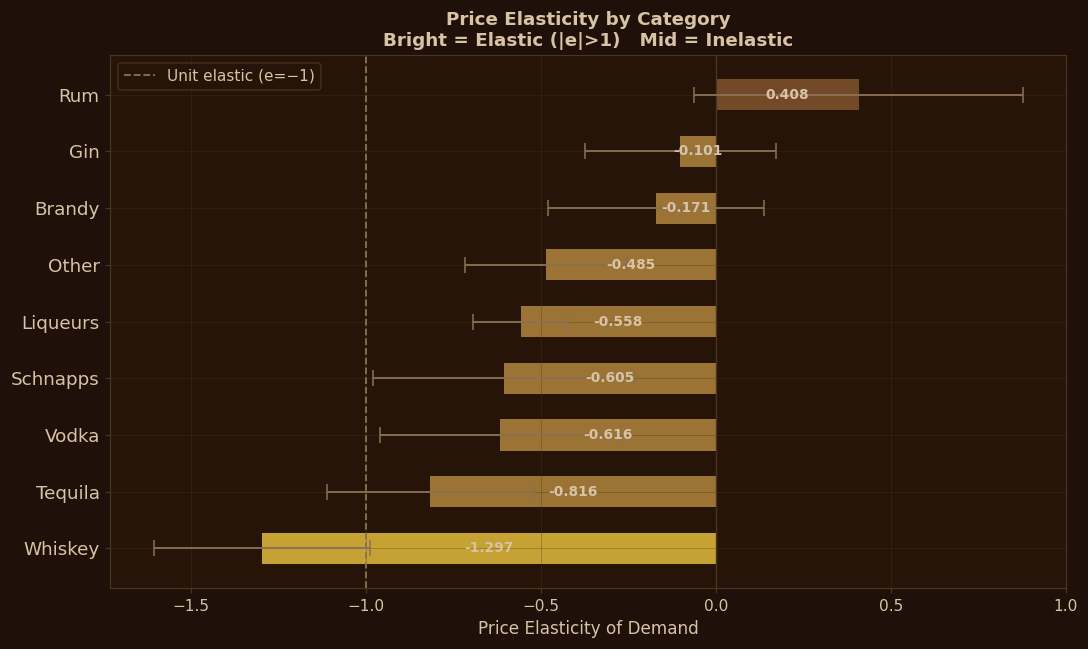

In [60]:
m4 = pf.feols(
    'log_liters_pa ~ log_price:category + holiday_days | county + category + month + year',
    data=panel, vcov={'CRV1': 'county'}
)
show_results(m4, 'Category-Specific Elasticity')

tidy_m4 = m4.tidy()
cat_coefs = tidy_m4[tidy_m4.index.str.contains('log_price:category')].copy()
cat_coefs['category'] = [
    re.search(r'\[([^\]]+)\]', str(idx)).group(1)
    if re.search(r'\[([^\]]+)\]', str(idx)) else str(idx)
    for idx in cat_coefs.index
]
cat_coefs = cat_coefs.sort_values('Estimate')

fig, ax = plt.subplots(figsize=(10, 6))
apply_dark_style(fig, [ax])
bar_colors = [GOLD_BRIGHT if v < -1 else (GOLD_WARM if v < 0 else GOLD_DARK)
              for v in cat_coefs['Estimate']]
ax.axvline(-1, color=TEXT_DIM, linestyle='--', linewidth=1.2, label='Unit elastic (e=−1)')
ax.axvline(0, color=AXIS_COLOR, linewidth=0.9)
ax.barh(cat_coefs['category'], cat_coefs['Estimate'],
        xerr=1.96 * cat_coefs['Std. Error'],
        color=bar_colors, capsize=5, alpha=0.92, height=0.55,
        error_kw=dict(ecolor=TEXT_DIM, linewidth=1.2))
for _, row in cat_coefs.iterrows():
    label_x = row['Estimate'] / 2
    ax.text(label_x, row['category'], f"{row['Estimate']:.3f}",
            va='center', ha='center', fontsize=9, fontweight='bold', color=TEXT_CREAM)
ax.set_title('Price Elasticity by Category\nBright = Elastic (|e|>1)   Mid = Inelastic',
             fontweight='bold', fontsize=12, color=TEXT_CREAM)
ax.set_xlabel('Price Elasticity of Demand', fontsize=11, color=TEXT_CREAM)
ax.tick_params(axis='y', labelsize=12, labelcolor=TEXT_CREAM)
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/category_elasticity.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


## M5 - Urban vs. Rural Elasticity


  Market-Type Elasticity
                                     Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                                              
holiday_days                          -0.0320      0.0063    0.0000   ***
log_price:market_type[Metro]          -0.0615      0.2138    0.7741      
log_price:market_type[Micropolitan]   -0.2904      0.1394    0.0398    **
log_price:market_type[Rural]          -0.5045      0.0654    0.0000   ***

  N = 49,238  |  R2 = 0.8703  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


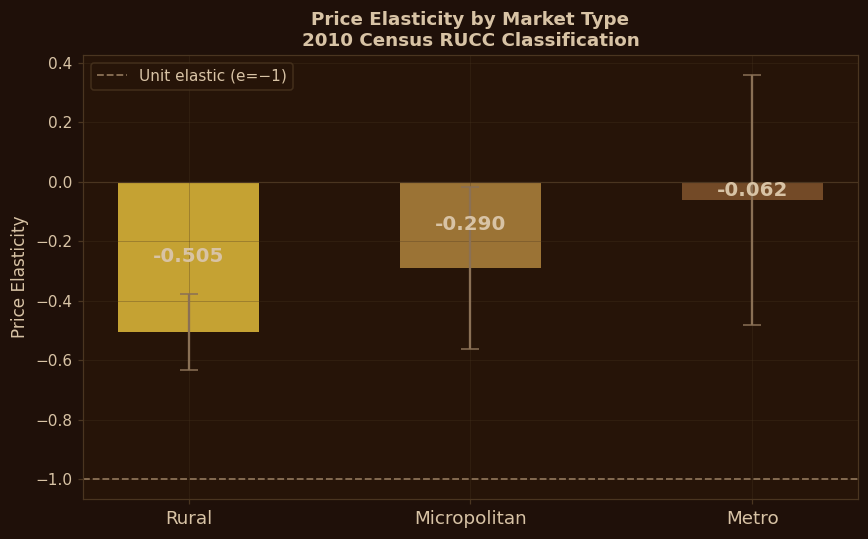

In [61]:
m5 = pf.feols(
    'log_liters_pa ~ log_price:market_type + holiday_days | county + category + month + year',
    data=panel, vcov={'CRV1': 'county'}
)
show_results(m5, 'Market-Type Elasticity')

tidy_m5  = m5.tidy()
mkt_coefs = tidy_m5[tidy_m5.index.str.contains('log_price:market_type')].copy()
mkt_coefs['market'] = [
    re.search(r'\[([^\]]+)\]', str(idx)).group(1)
    if re.search(r'\[([^\]]+)\]', str(idx)) else str(idx)
    for idx in mkt_coefs.index
]
order_m = ['Rural', 'Micropolitan', 'Metro']
mkt_coefs['ord'] = mkt_coefs['market'].map({m: i for i, m in enumerate(order_m)})
mkt_coefs = mkt_coefs.sort_values('ord')
colors_mkt = {'Rural': GOLD_BRIGHT, 'Micropolitan': GOLD_WARM, 'Metro': GOLD_DARK}

fig, ax = plt.subplots(figsize=(8, 5))
apply_dark_style(fig, [ax])
for _, row in mkt_coefs.iterrows():
    c = colors_mkt.get(row['market'], GOLD_MID)
    ax.bar(row['market'], row['Estimate'], yerr=1.96 * row['Std. Error'],
           color=c, alpha=0.92, capsize=6, width=0.5,
           error_kw=dict(ecolor=TEXT_DIM, linewidth=1.5))
    ax.text(row['market'], row['Estimate'] / 2, f"{row['Estimate']:.3f}",
            ha='center', va='center', fontsize=13, fontweight='bold', color=TEXT_CREAM)
ax.axhline(-1, color=TEXT_DIM, linestyle='--', linewidth=1.2, label='Unit elastic (e=−1)')
ax.axhline(0, color=AXIS_COLOR, linewidth=0.8)
ax.set_title('Price Elasticity by Market Type\n2010 Census RUCC Classification',
             fontweight='bold', fontsize=12, color=TEXT_CREAM)
ax.set_ylabel('Price Elasticity', fontsize=11, color=TEXT_CREAM)
ax.tick_params(axis='x', labelsize=12, labelcolor=TEXT_CREAM)
ax.tick_params(axis='y', labelsize=10, labelcolor=TEXT_CREAM)
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/market_type_elasticity.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


## M6 - Category x Market Type Interaction


  Category x Market-Type Elasticity
                                                        Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                                                                 
holiday_days                                             -0.0318      0.0062    0.0000   ***
log_price:category[Brandy]:market_type[Metro]            -0.2132      0.4336    0.6241      
log_price:category[Gin]:market_type[Metro]               -0.1216      0.5028    0.8095      
log_price:category[Liqueurs]:market_type[Metro]          -0.6418      0.4488    0.1559      
log_price:category[Other]:market_type[Metro]             -0.4771      0.3843    0.2174      
log_price:category[Rum]:market_type[Metro]                0.2109      0.5231    0.6877      
log_price:category[Schnapps]:market_type[Metro]          -0.4488      0.4836    0.3557      
log_price:category[Tequila]:market_type[Metro]           -0.7402      0.4540    0.1062      
log_price:category[Vodka]:market_

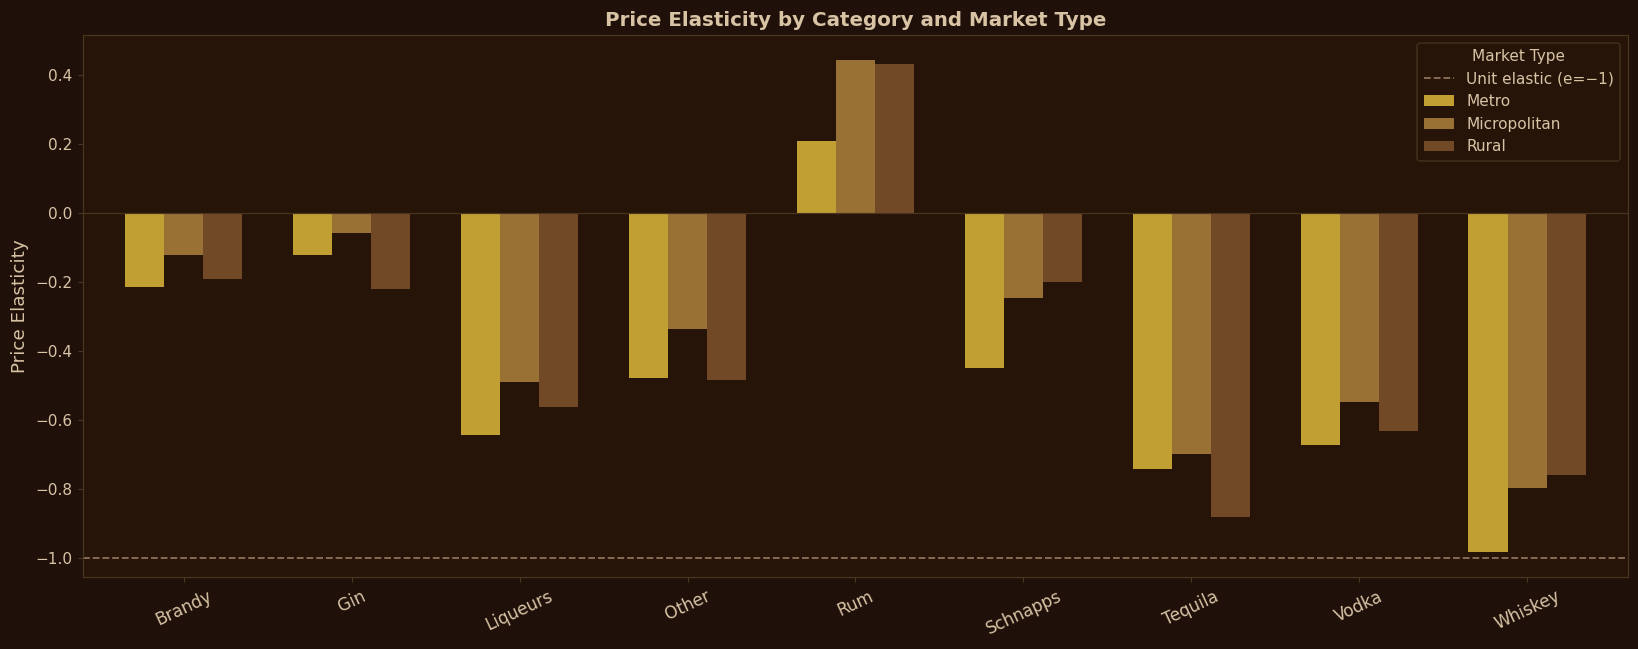

In [62]:
m6 = pf.feols(
    'log_liters_pa ~ log_price:category:market_type + holiday_days | county + category + month + year',
    data=panel, vcov={'CRV1': 'county'}
)
show_results(m6, 'Category x Market-Type Elasticity')

tidy_m6 = m6.tidy()
ic = tidy_m6[tidy_m6.index.str.startswith('log_price:')].copy()
ic['category'] = [re.search(r'category\[([^\]]+)\]', str(s)).group(1)
                  if re.search(r'category\[([^\]]+)\]', str(s)) else None for s in ic.index]
ic['market']   = [re.search(r'market_type\[([^\]]+)\]', str(s)).group(1)
                  if re.search(r'market_type\[([^\]]+)\]', str(s)) else None for s in ic.index]
ic = ic.dropna(subset=['category', 'market'])
pivot = ic.pivot_table(index='category', columns='market', values='Estimate', aggfunc='mean')

fig, ax = plt.subplots(figsize=(15, 6))
apply_dark_style(fig, [ax])
pivot.plot(kind='bar', ax=ax, alpha=0.90, width=0.70,
           color=[GOLD_BRIGHT, GOLD_WARM, GOLD_DARK])
ax.axhline(-1, color=TEXT_DIM, linestyle='--', linewidth=1.2, label='Unit elastic (e=−1)')
ax.axhline(0, color=AXIS_COLOR, linewidth=0.8)
ax.set_title('Price Elasticity by Category and Market Type', fontweight='bold', fontsize=13, color=TEXT_CREAM)
ax.set_ylabel('Price Elasticity', fontsize=12, color=TEXT_CREAM)
ax.set_xlabel('', color=TEXT_CREAM)
ax.tick_params(axis='x', rotation=25, labelsize=11, labelcolor=TEXT_CREAM)
ax.tick_params(axis='y', labelsize=10, labelcolor=TEXT_CREAM)
leg = ax.legend(title='Market Type', fontsize=10, title_fontsize=10,
                facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
leg.get_title().set_color(TEXT_CREAM)
ax.set_facecolor(PANEL_BG)
plt.tight_layout()
plt.savefig('figures/category_x_market_elasticity.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


---
# 7. Heterogeneity - Granular Analysis (M4b, M5b, M5c)

These models retain all 130 granular categories and all 99 counties.

## M4b - Granular Category Elasticity (130 Categories)

Separate OLS per category. Reveals ultra-elastic niche items invisible in the consolidated model.

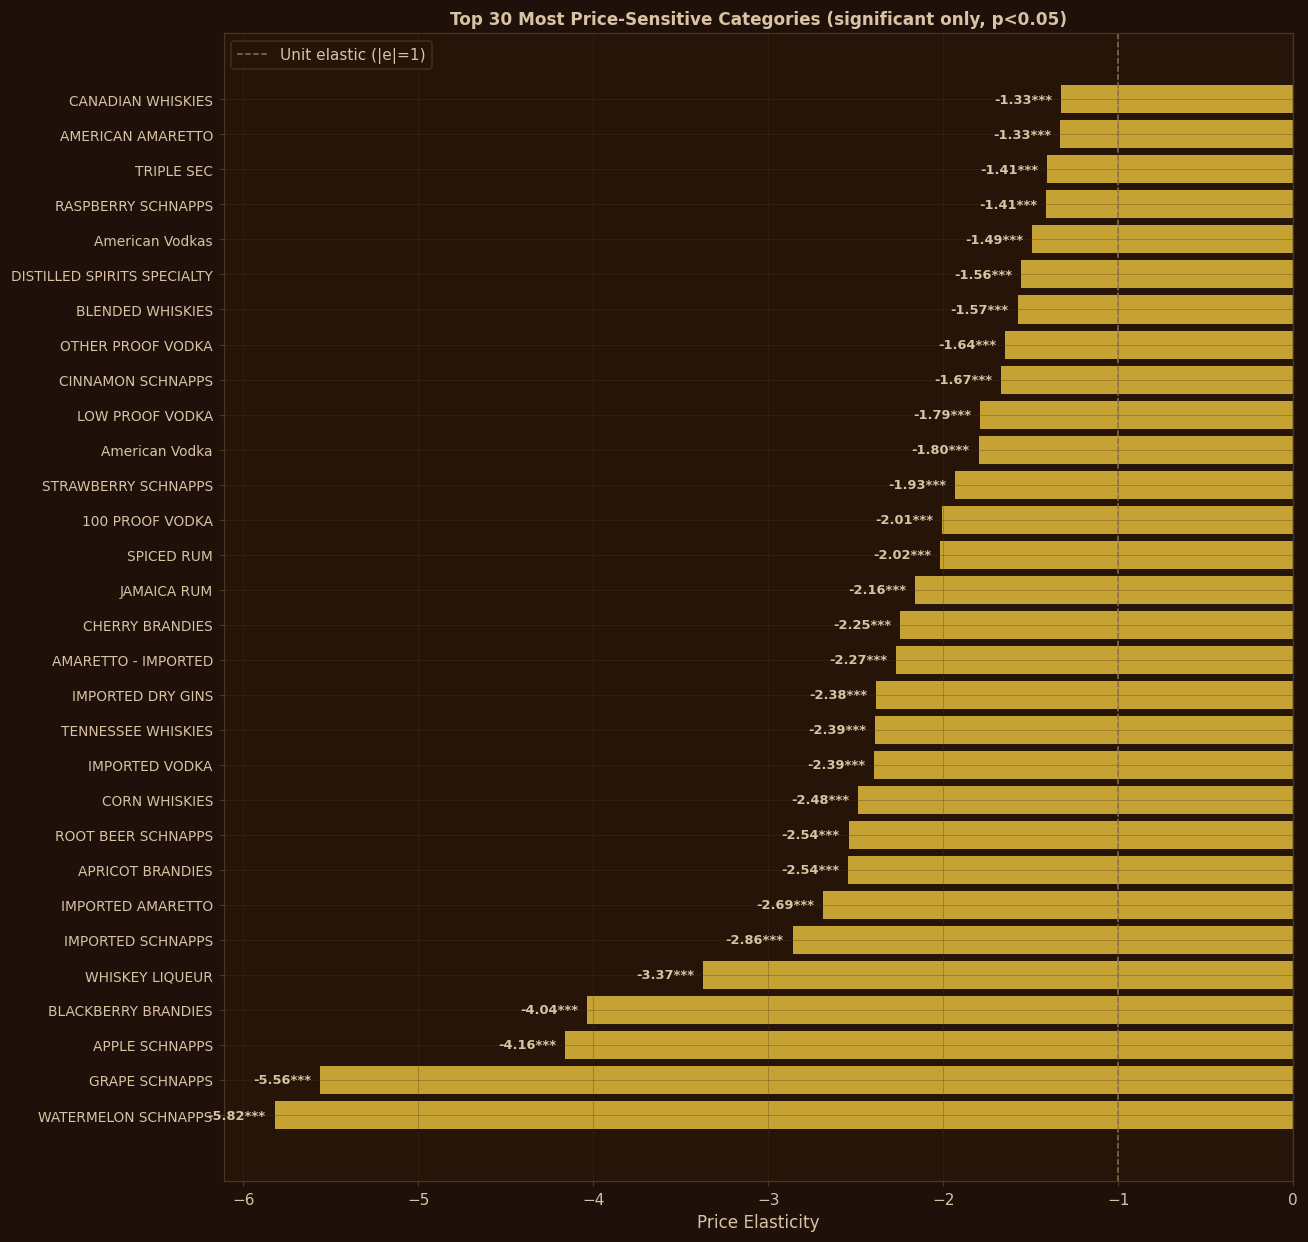


Top 5 most price-sensitive categories:
           Category  Elasticity  p_value     R2    N
WATERMELON SCHNAPPS     -5.8209   0.0000 0.0820 4083
     GRAPE SCHNAPPS     -5.5626   0.0000 0.0611 3347
     APPLE SCHNAPPS     -4.1586   0.0000 0.0756 4768
BLACKBERRY BRANDIES     -4.0365   0.0000 0.1012 5242
    WHISKEY LIQUEUR     -3.3736   0.0000 0.0429 5500


In [63]:
cat_elas = []
for cat, grp in agg.groupby('Category Name'):
    grp = grp.dropna(subset=['log_price', 'log_demand'])
    if len(grp) < 30:
        continue
    X_c = sm.add_constant(grp['log_price'])
    res = sm.OLS(grp['log_demand'], X_c).fit()
    cat_elas.append({
        'Category':   cat,
        'Elasticity': res.params['log_price'],
        'p_value':    res.pvalues['log_price'],
        'R2':         res.rsquared,
        'N':          len(grp),
    })

cat_df  = pd.DataFrame(cat_elas).sort_values('Elasticity')
cat_sig = cat_df[cat_df['p_value'] < 0.05].head(30)

fig, ax = plt.subplots(figsize=(12, max(6, len(cat_sig) * 0.38)))
apply_dark_style(fig, [ax])
bar_c = [GOLD_BRIGHT if e < -1 else (GOLD_WARM if e < 0 else GOLD_DARK) for e in cat_sig['Elasticity']]
ax.barh(cat_sig['Category'], cat_sig['Elasticity'], color=bar_c, alpha=0.92)
for i, (_, row) in enumerate(cat_sig.iterrows()):
    star = '***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01 else '*')
    ax.text(row['Elasticity'] - 0.05, i, f"{row['Elasticity']:.2f}{star}",
            va='center', ha='right', fontsize=8.5, fontweight='bold', color=TEXT_CREAM)
ax.axvline(0, color=AXIS_COLOR, linewidth=0.9)
ax.axvline(-1, color=TEXT_DIM, linewidth=1, linestyle='--', label='Unit elastic (|e|=1)')
ax.set_xlabel('Price Elasticity', fontsize=11, color=TEXT_CREAM)
ax.set_title('Top 30 Most Price-Sensitive Categories (significant only, p<0.05)',
             fontsize=11, fontweight='bold', color=TEXT_CREAM)
ax.tick_params(axis='y', labelsize=9, labelcolor=TEXT_CREAM)
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/granular_category_elasticity.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()

print('\nTop 5 most price-sensitive categories:')
print(cat_df.head(5)[['Category','Elasticity','p_value','R2','N']].to_string(index=False))


## M5b - County-Level Price Sensitivity

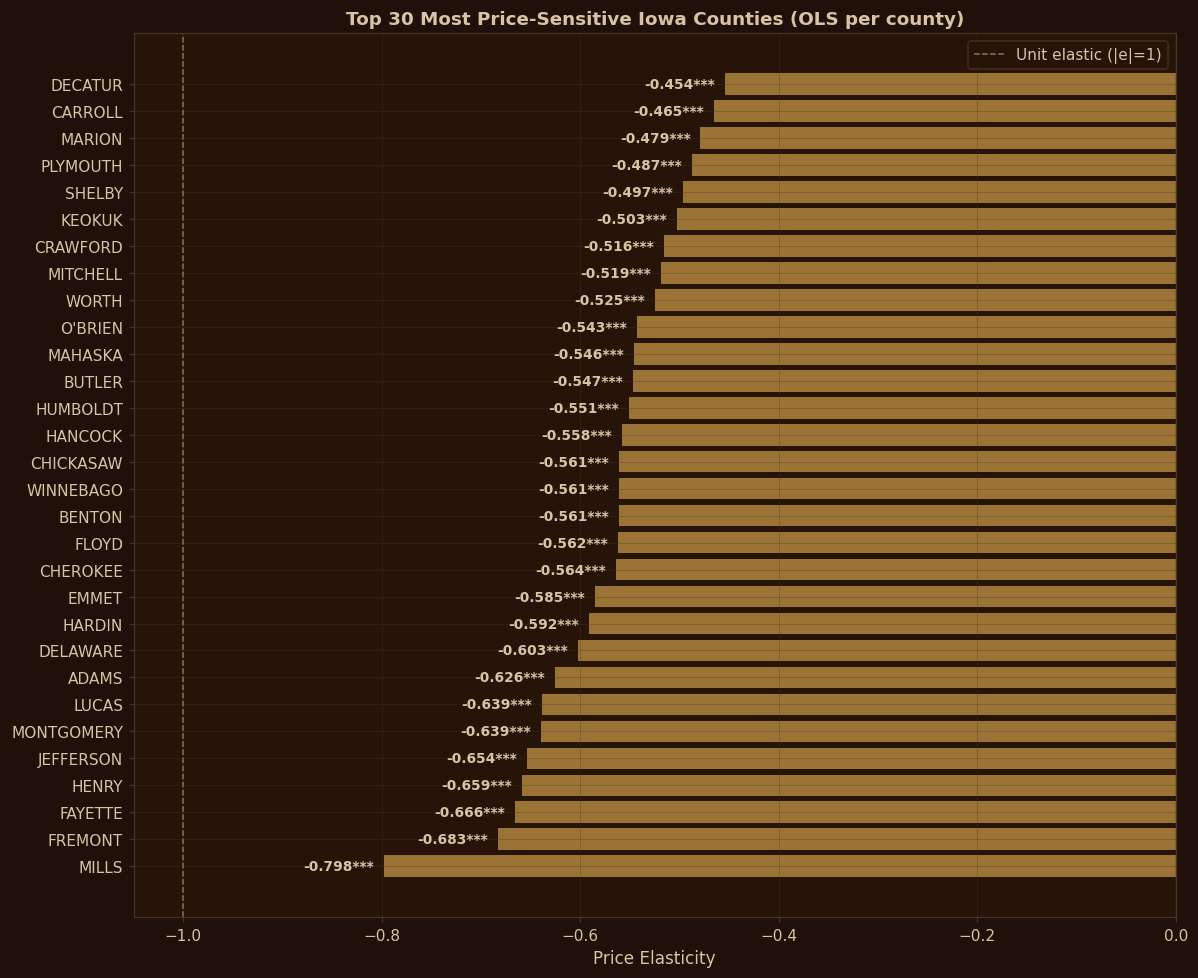


Most price-sensitive counties:
   County  Elasticity  p_value     R2    N
    MILLS     -0.7982   0.0000 0.1415 2422
  FREMONT     -0.6825   0.0000 0.3839  517
  FAYETTE     -0.6658   0.0000 0.0793 3388
    HENRY     -0.6589   0.0000 0.1108 3214
JEFFERSON     -0.6537   0.0000 0.1049 3196


In [64]:
county_elas = []
for county, grp in agg.groupby('County'):
    grp = grp.dropna(subset=['log_price', 'log_demand'])
    if len(grp) < 30:
        continue
    X_c = sm.add_constant(grp['log_price'])
    res = sm.OLS(grp['log_demand'], X_c).fit()
    county_elas.append({
        'County':     county,
        'Elasticity': res.params['log_price'],
        'p_value':    res.pvalues['log_price'],
        'R2':         res.rsquared,
        'N':          len(grp),
    })

county_df  = pd.DataFrame(county_elas).sort_values('Elasticity')
county_top = county_df.head(30)

fig, ax = plt.subplots(figsize=(11, 9))
apply_dark_style(fig, [ax])
bar_c = [GOLD_BRIGHT if e < -1 else GOLD_WARM for e in county_top['Elasticity']]
ax.barh(county_top['County'], county_top['Elasticity'], color=bar_c, alpha=0.92)
for i, (_, row) in enumerate(county_top.iterrows()):
    star = ('***' if row['p_value'] < 0.001 else ('**' if row['p_value'] < 0.01
            else ('*' if row['p_value'] < 0.05 else '')))
    ax.text(row['Elasticity'] - 0.01, i, f"{row['Elasticity']:.3f}{star}",
            va='center', ha='right', fontsize=9, fontweight='bold', color=TEXT_CREAM)
ax.axvline(0, color=AXIS_COLOR, linewidth=0.9)
ax.axvline(-1, color=TEXT_DIM, linewidth=1, linestyle='--', label='Unit elastic (|e|=1)')
ax.set_xlabel('Price Elasticity', fontsize=11, color=TEXT_CREAM)
ax.set_title('Top 30 Most Price-Sensitive Iowa Counties (OLS per county)',
             fontsize=12, fontweight='bold', color=TEXT_CREAM)
ax.tick_params(axis='y', labelsize=10, labelcolor=TEXT_CREAM)
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/county_elasticity.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()

print('\nMost price-sensitive counties:')
print(county_df.head(5)[['County','Elasticity','p_value','R2','N']].to_string(index=False))


## M5c - Price Elasticity Heatmap: Top Counties x Top Categories

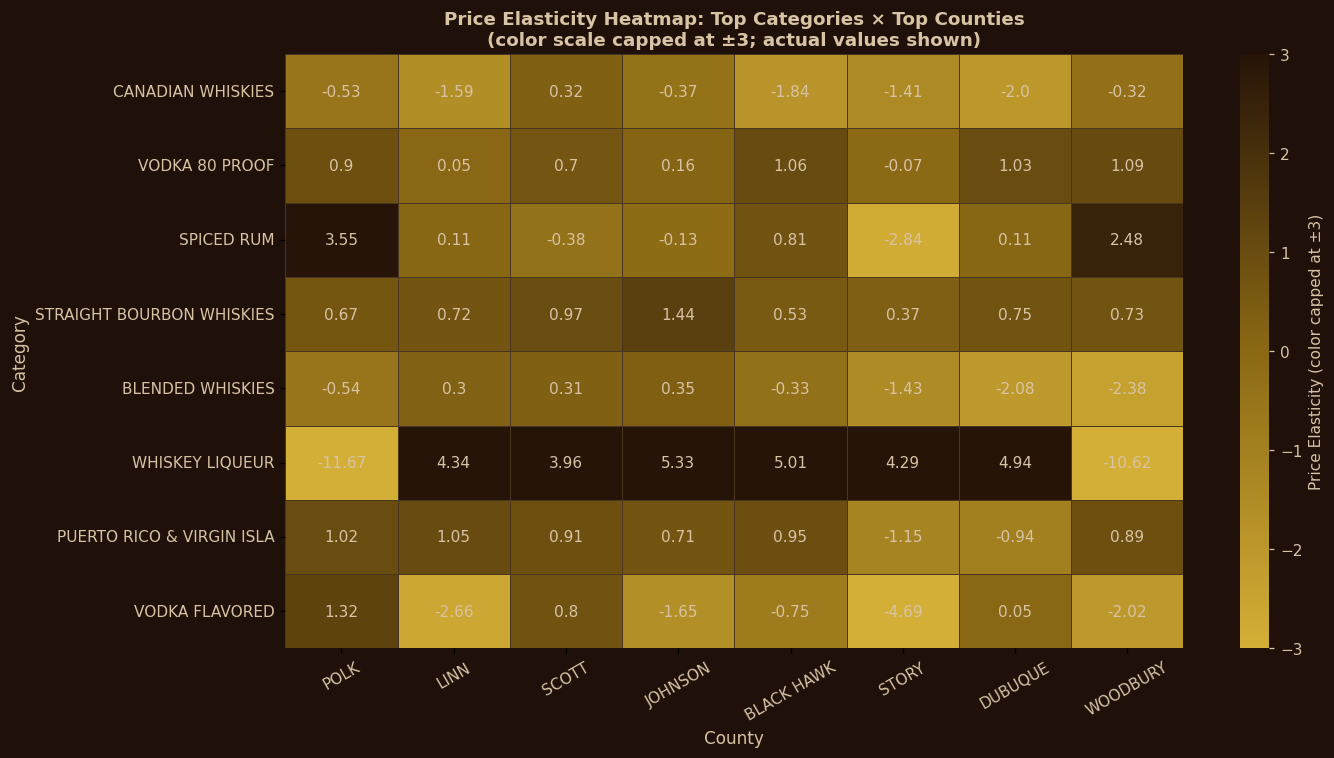

Takeaway: Gold cells = most elastic (highest risk from price hikes / best for promotions).


In [65]:
top8_counties = agg['County'].value_counts().head(8).index.tolist()
top8_cats     = agg['Category Name'].value_counts().head(8).index.tolist()

heat_elas = {}
for cat in top8_cats:
    row = {}
    for county in top8_counties:
        sub = agg[(agg['County'] == county) & (agg['Category Name'] == cat)]
        sub = sub.dropna(subset=['log_price', 'log_demand'])
        if len(sub) < 10:
            row[county] = np.nan
        else:
            res = sm.OLS(sub['log_demand'], sm.add_constant(sub['log_price'])).fit()
            row[county] = res.params['log_price']
    heat_elas[cat[:25]] = row

heat_df      = pd.DataFrame(heat_elas).T
heat_display = heat_df.clip(lower=-3, upper=3)

cmap_div = LinearSegmentedColormap.from_list('div3', [GOLD_BRIGHT, '#8B6914', PANEL_BG], N=256)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL_BG)
sns.heatmap(heat_display, cmap=cmap_div, center=0, vmin=-3, vmax=3,
            annot=heat_df.round(2), fmt='', annot_kws={'size': 10, 'color': TEXT_CREAM},
            linewidths=0.5, linecolor=AXIS_COLOR, ax=ax,
            cbar_kws={'label': 'Price Elasticity (color capped at ±3)'})
cbar = ax.collections[0].colorbar
cbar.set_label('Price Elasticity (color capped at ±3)', color=TEXT_CREAM)
cbar.ax.yaxis.set_tick_params(color=TEXT_CREAM, labelcolor=TEXT_CREAM)
ax.set_title('Price Elasticity Heatmap: Top Categories × Top Counties\n'
             '(color scale capped at ±3; actual values shown)',
             fontsize=12, fontweight='bold', color=TEXT_CREAM)
ax.set_xlabel('County', fontsize=11, color=TEXT_CREAM)
ax.set_ylabel('Category', fontsize=11, color=TEXT_CREAM)
ax.tick_params(axis='x', labelsize=10, rotation=30, labelcolor=TEXT_CREAM)
ax.tick_params(axis='y', labelsize=10, rotation=0, labelcolor=TEXT_CREAM)
for sp in ax.spines.values():
    sp.set_edgecolor(AXIS_COLOR)
plt.tight_layout()
plt.savefig('figures/county_category_heatmap.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()
print('Takeaway: Gold cells = most elastic (highest risk from price hikes / best for promotions).')


---
# 8. Calendar and Timing Models (M7 - M9)

## M7 - Holiday x Price Interaction

Tests whether price sensitivity changes during holiday/weekend-heavy months.


  Holiday x Price Interaction
                        Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                                 
log_price                -0.4777      0.0642    0.0000   ***
holiday_days             -0.1196      0.0292    0.0001   ***
log_price:holiday_days    0.0333      0.0105    0.0021   ***

  N = 49,238  |  R2 = 0.8698  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


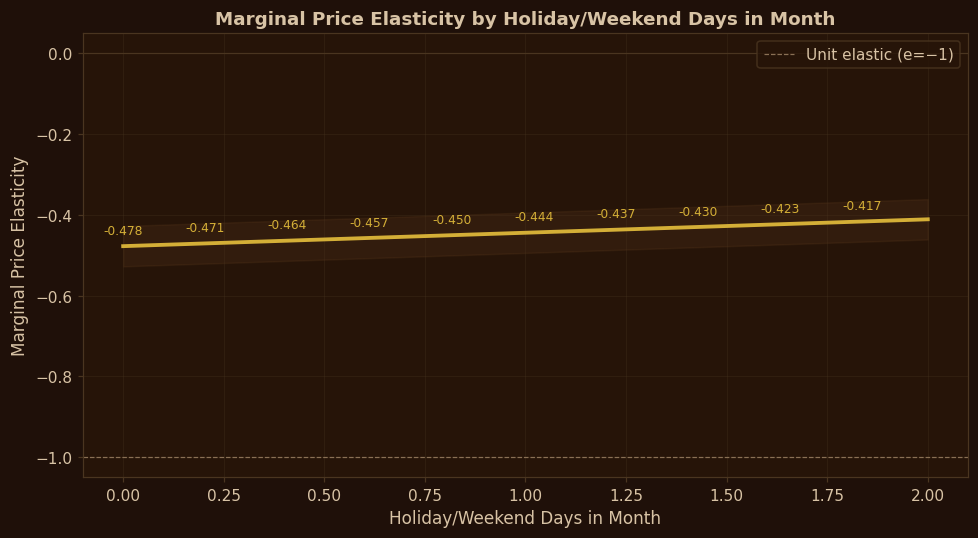

In [66]:
m7 = pf.feols(
    'log_liters_pa ~ log_price + holiday_days + log_price:holiday_days | county + category + month + year',
    data=panel, vcov={'CRV1': 'county'}
)
show_results(m7, 'Holiday x Price Interaction')

tidy_m7    = m7.tidy()
b_price    = tidy_m7.loc[tidy_m7.index == 'log_price', 'Estimate'].values[0]
b_interact = tidy_m7.loc[tidy_m7.index.str.contains('log_price:holiday_days'), 'Estimate'].values[0]
hol_range  = np.linspace(0, panel['holiday_days'].quantile(0.95), 50)
elas_line  = b_price + b_interact * hol_range

fig, ax = plt.subplots(figsize=(9, 5))
apply_dark_style(fig, [ax])
ax.fill_between(hol_range, elas_line - 0.05, elas_line + 0.05, alpha=0.15, color=GOLD_DARK)
ax.plot(hol_range, elas_line, color=GOLD_BRIGHT, linewidth=2.5)
for x, y in zip(hol_range[::5], elas_line[::5]):
    ax.annotate(f'{y:.3f}', xy=(x, y), xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color=GOLD_BRIGHT)
ax.axhline(0, color=AXIS_COLOR, linewidth=0.8)
ax.axhline(-1, color=TEXT_DIM, linewidth=0.8, linestyle='--', label='Unit elastic (e=−1)')
ax.set_xlabel('Holiday/Weekend Days in Month', fontsize=11, color=TEXT_CREAM)
ax.set_ylabel('Marginal Price Elasticity', fontsize=11, color=TEXT_CREAM)
ax.set_title('Marginal Price Elasticity by Holiday/Weekend Days in Month',
             fontweight='bold', fontsize=12, color=TEXT_CREAM)
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/holiday_price_interaction.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


## M7b - Marginal Elasticity Across Weekend Activity

Visualises how price sensitivity varies with weekend activity for holiday vs non-holiday periods.

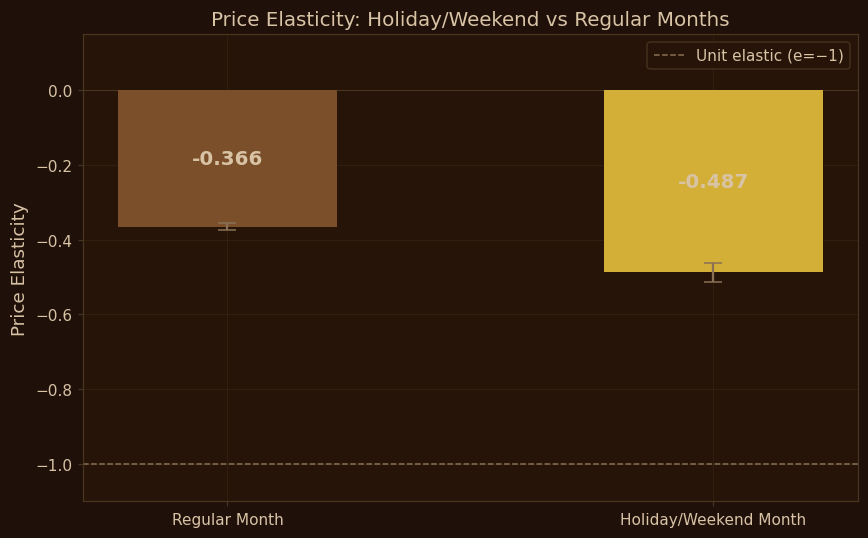

In [67]:
# Price Elasticity by Holiday/Weekend vs Regular Months
hol_elas = []
for is_hol, label in [(0, 'Regular Month'), (1, 'Holiday/Weekend Month')]:
    sub = agg[agg['Is_Holiday'] == is_hol].copy()
    if len(sub) < 50:
        continue
    X_h = sm.add_constant(sub['log_price'])
    m_h = sm.OLS(sub['log_demand'], X_h).fit(cov_type='HC3')
    hol_elas.append({
        'label':      label,
        'elasticity': m_h.params['log_price'],
        'ci_lo':      m_h.conf_int().loc['log_price', 0],
        'ci_hi':      m_h.conf_int().loc['log_price', 1],
    })
hdf  = pd.DataFrame(hol_elas)
yerr = np.array([[h['elasticity'] - h['ci_lo'], h['ci_hi'] - h['elasticity']]
                 for _, h in hdf.iterrows()]).T

fig, ax = plt.subplots(figsize=(8, 5))
apply_dark_style(fig, [ax])
bars = ax.bar(hdf['label'], hdf['elasticity'],
              color=[GOLD_DARK, GOLD_BRIGHT],
              yerr=yerr, capsize=6, error_kw={'linewidth': 1.5, 'ecolor': TEXT_DIM},
              width=0.45, zorder=3)
for bar, row in zip(bars, hdf.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, row.elasticity / 2,
            f'{row.elasticity:.3f}', ha='center', va='center',
            color=TEXT_CREAM, fontweight='bold', fontsize=13)
ax.axhline(-1, color=TEXT_DIM, linestyle='--', linewidth=1, label='Unit elastic (e=−1)')
ax.axhline(0, color=AXIS_COLOR, linewidth=0.7)
ax.set_ylabel('Price Elasticity', fontsize=12, color=TEXT_CREAM)
ax.set_title('Price Elasticity: Holiday/Weekend vs Regular Months',
             fontsize=13, color=TEXT_CREAM)
ax.set_ylim(min(hdf['ci_lo'].min() - 0.1, -1.1), 0.15)
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
ax.tick_params(labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/holiday_vs_regular_elasticity.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


## M8 - Month x Price Interaction (Seasonal Elasticity)

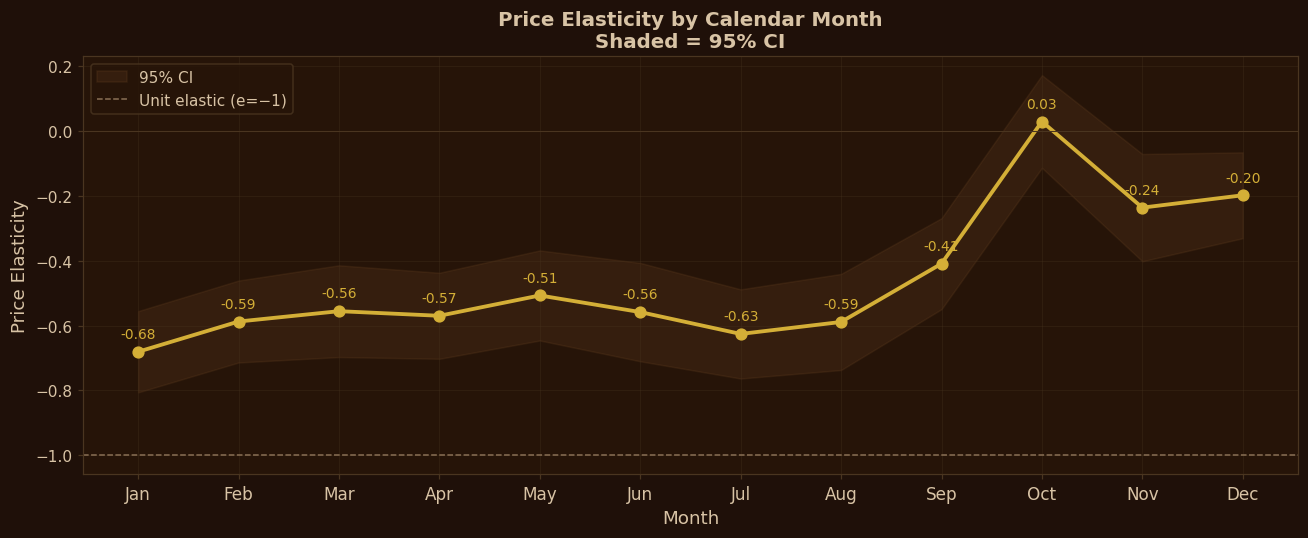

In [68]:
m8 = pf.feols(
    'log_liters_pa ~ log_price:month_str + holiday_days | county + category + month + year',
    data=panel, vcov={'CRV1': 'county'}
)

tidy_m8     = m8.tidy()
month_coefs = tidy_m8[tidy_m8.index.str.contains('log_price:month_str')].copy()

def extract_month(s):
    match = re.search(r'(\d+)', str(s).replace('log_price', ''))
    return int(match.group(1)) if match else None

month_coefs['month_n'] = [extract_month(i) for i in month_coefs.index]
month_coefs = month_coefs.dropna(subset=['month_n'])
month_coefs['month_n'] = month_coefs['month_n'].astype(int)
month_coefs = month_coefs.sort_values('month_n')
month_labels_list = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_coefs['month_label'] = month_coefs['month_n'].apply(lambda x: month_labels_list[x - 1])

fig, ax = plt.subplots(figsize=(12, 5))
apply_dark_style(fig, [ax])
ax.fill_between(
    month_coefs['month_n'],
    month_coefs['Estimate'] - 1.96 * month_coefs['Std. Error'],
    month_coefs['Estimate'] + 1.96 * month_coefs['Std. Error'],
    alpha=0.18, color=GOLD_DARK, label='95% CI'
)
ax.plot(month_coefs['month_n'], month_coefs['Estimate'],
        'o-', color=GOLD_BRIGHT, linewidth=2.5, markersize=7)
for _, row in month_coefs.iterrows():
    ax.annotate(f"{row['Estimate']:.2f}",
                xy=(row['month_n'], row['Estimate']),
                xytext=(0, 9), textcoords='offset points',
                ha='center', fontsize=9, color=GOLD_BRIGHT)
ax.axhline(-1, color=TEXT_DIM, linestyle='--', linewidth=1, label='Unit elastic (e=−1)')
ax.axhline(0, color=AXIS_COLOR, linewidth=0.7)
ax.set_xticks(month_coefs['month_n'])
ax.set_xticklabels(month_coefs['month_label'], fontsize=11, color=TEXT_CREAM)
ax.set_xlabel('Month', fontsize=12, color=TEXT_CREAM)
ax.set_ylabel('Price Elasticity', fontsize=12, color=TEXT_CREAM)
ax.set_title('Price Elasticity by Calendar Month\nShaded = 95% CI',
             fontsize=13, fontweight='bold', color=TEXT_CREAM)
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/seasonal_elasticity_by_month.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


## M9 - Year Trend in Elasticity

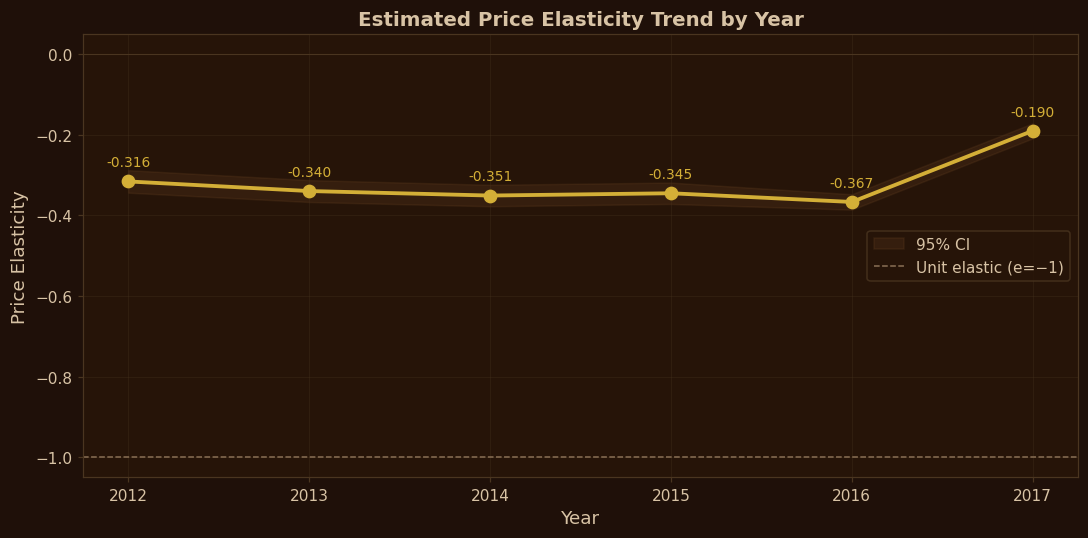


Elasticity by year:
 Year  Elasticity   ci_lo   ci_hi
 2012     -0.3156 -0.3435 -0.2877
 2013     -0.3395 -0.3667 -0.3123
 2014     -0.3507 -0.3773 -0.3241
 2015     -0.3450 -0.3715 -0.3185
 2016     -0.3666 -0.3858 -0.3475
 2017     -0.1899 -0.2086 -0.1712


In [69]:
# Year trend: per-year OLS on agg (all categories, includes 2017)
year_elas_list = []
for yr in sorted(agg['Year'].unique()):
    sub = agg[agg['Year'] == yr].dropna(subset=['log_demand', 'log_price'])
    if len(sub) < 100:
        continue
    X_yr = sm.add_constant(sub['log_price'])
    m_yr = sm.OLS(sub['log_demand'], X_yr).fit(cov_type='HC3')
    year_elas_list.append({
        'Year':       yr,
        'Elasticity': m_yr.params['log_price'],
        'ci_lo':      m_yr.conf_int().loc['log_price', 0],
        'ci_hi':      m_yr.conf_int().loc['log_price', 1],
    })
ydf = pd.DataFrame(year_elas_list)

fig, ax = plt.subplots(figsize=(10, 5))
apply_dark_style(fig, [ax])
ax.fill_between(ydf['Year'], ydf['ci_lo'], ydf['ci_hi'],
                alpha=0.18, color=GOLD_DARK, label='95% CI')
ax.plot(ydf['Year'], ydf['Elasticity'], 'o-', color=GOLD_BRIGHT, linewidth=2.5, markersize=8)
for _, row in ydf.iterrows():
    ax.annotate(f"{row['Elasticity']:.3f}",
                xy=(row['Year'], row['Elasticity']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color=GOLD_BRIGHT)
ax.axhline(-1, color=TEXT_DIM, linestyle='--', linewidth=1, label='Unit elastic (e=−1)')
ax.axhline(0, color=AXIS_COLOR, linewidth=0.7)
ax.set_xlabel('Year', fontsize=12, color=TEXT_CREAM)
ax.set_ylabel('Price Elasticity', fontsize=12, color=TEXT_CREAM)
ax.set_title('Estimated Price Elasticity Trend by Year', fontweight='bold', fontsize=13, color=TEXT_CREAM)
ax.set_xticks(ydf['Year'])
ax.tick_params(labelcolor=TEXT_CREAM)
ax.legend(fontsize=10, facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)
plt.tight_layout()
plt.savefig('figures/year_trend_elasticity.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()

print('\nElasticity by year:')
print(ydf[['Year','Elasticity','ci_lo','ci_hi']].to_string(index=False))


---
# 9. Dynamic Demand Models (M10 - M11)

## M10 - Lagged Demand (Habit Persistence)

- **Short-run elasticity** = beta_1 (immediate demand response)
- **Long-run elasticity** = beta_1 / (1 - beta_2) (full effect after habits adjust)

In [70]:
panel_lag = panel.dropna(subset=['log_liters_pa_lag'])

m10 = pf.feols(
    'log_liters_pa ~ log_price + log_liters_pa_lag + holiday_days | county + category + month + year',
    data=panel_lag, vcov={'CRV1': 'county'}
)
show_results(m10, 'M10: Lagged Demand - Habit Persistence')

sr_elas  = m10.coef()['log_price']
lag_coef = m10.coef()['log_liters_pa_lag']
lr_elas  = sr_elas / (1 - lag_coef)

print('\n' + '='*50)
print('  Dynamic Elasticity Decomposition')
print('='*50)
print(f'  Short-run elasticity (b1):           {sr_elas:.4f}')
print(f'  Lag coefficient (b2):                {lag_coef:.4f}')
print(f'  Long-run elasticity (b1 / (1-b2)):  {lr_elas:.4f}')
print(f'\n  Long-run effect is {abs(lr_elas/sr_elas):.1f}x larger than short-run')
print(f'  Demand shows {"strong" if lag_coef > 0.3 else "moderate"} month-to-month persistence')


  M10: Lagged Demand - Habit Persistence
                   Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                            
log_price           -0.3587      0.0441    0.0000   ***
log_liters_pa_lag    0.4547      0.0174    0.0000   ***
holiday_days        -0.0134      0.0067    0.0490    **

  N = 48,347  |  R2 = 0.8972  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01

  Dynamic Elasticity Decomposition
  Short-run elasticity (b1):           -0.3587
  Lag coefficient (b2):                0.4547
  Long-run elasticity (b1 / (1-b2)):  -0.6577

  Long-run effect is 1.8x larger than short-run
  Demand shows strong month-to-month persistence


## M11 - Distributed Price Lag

In [71]:
panel_distlag = panel.dropna(subset=['log_price_lag', 'log_liters_pa_lag'])

m11 = pf.feols(
    'log_liters_pa ~ log_price + log_price_lag + holiday_days | county + category + month + year',
    data=panel_distlag, vcov={'CRV1': 'county'}
)
show_results(m11, 'M11: Distributed Price Lag')

b_cur = m11.coef()['log_price']
b_lag = m11.coef()['log_price_lag']
print(f'\nContemporaneous elasticity (b1): {b_cur:.4f}')
print(f'Lagged price elasticity (b2):    {b_lag:.4f}')
print(f'Total effect (b1 + b2):          {b_cur + b_lag:.4f}')
print('\nIf b2 is not significant: price effects are immediate with no echo month-over-month.')


  M11: Distributed Price Lag
               Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                        
log_price       -0.4448      0.0544    0.0000   ***
log_price_lag   -0.0444      0.0387    0.2547      
holiday_days    -0.0277      0.0066    0.0001   ***

  N = 48,347  |  R2 = 0.8699  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01

Contemporaneous elasticity (b1): -0.4448
Lagged price elasticity (b2):    -0.0444
Total effect (b1 + b2):          -0.4892

If b2 is not significant: price effects are immediate with no echo month-over-month.


---
# 10. Cross-Price Elasticity (M12)

Tests whether spirits are substitutes. Positive cross-price coefficient = substitutes.

In [72]:
cross_prices = (
    panel[panel['category'].isin(['Vodka', 'Whiskey'])]
    .groupby(['county', 'ym', 'category'])
    .apply(lambda g: np.average(g['avg_price_liter'], weights=g['total_liters']))
    .reset_index(name='avg_price')
    .pivot(index=['county', 'ym'], columns='category', values='avg_price')
    .reset_index()
    .rename(columns={'Vodka': 'price_vodka', 'Whiskey': 'price_whiskey'})
)
cross_prices['log_price_vodka']   = np.log(cross_prices['price_vodka'])
cross_prices['log_price_whiskey'] = np.log(cross_prices['price_whiskey'])

panel_vw = (
    panel[panel['category'].isin(['Vodka', 'Whiskey'])]
    .merge(cross_prices, on=['county', 'ym'], how='inner')
)

m12_vodka = pf.feols(
    'log_liters_pa ~ log_price_vodka + log_price_whiskey + holiday_days | county + month + year',
    data=panel_vw[panel_vw['category'] == 'Vodka'],
    vcov={'CRV1': 'county'}
)
m12_whiskey = pf.feols(
    'log_liters_pa ~ log_price_whiskey + log_price_vodka + holiday_days | county + month + year',
    data=panel_vw[panel_vw['category'] == 'Whiskey'],
    vcov={'CRV1': 'county'}
)

print('--- VODKA DEMAND ---')
show_results(m12_vodka, 'M12a: Vodka Demand (own + cross-price)')
print('\n--- WHISKEY DEMAND ---')
show_results(m12_whiskey, 'M12b: Whiskey Demand (own + cross-price)')

pf.etable(
    [m12_vodka, m12_whiskey],
    labels={
        'log_liters_pa': 'log(Liters/Adult)',
        'log_price_vodka': 'log(Vodka Price)',
        'log_price_whiskey': 'log(Whiskey Price)',
        'holiday_days': 'Holiday Days'
    },
    model_heads=['Vodka Demand', 'Whiskey Demand'],
    coef_fmt='b (se)',
    keep=['log_price_vodka', 'log_price_whiskey', 'holiday_days']
)

--- VODKA DEMAND ---

  M12a: Vodka Demand (own + cross-price)
                   Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                            
log_price_vodka     -0.3983      0.1370    0.0045   ***
log_price_whiskey    0.4056      0.0953    0.0000   ***
holiday_days        -0.0039      0.0085    0.6487      

  N = 5,532  |  R2 = 0.8678  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01

--- WHISKEY DEMAND ---

  M12b: Whiskey Demand (own + cross-price)
                   Estimate  Std. Error  Pr(>|t|) stars
Coefficient                                            
log_price_whiskey   -0.4661      0.1544    0.0032   ***
log_price_vodka      0.2983      0.0896    0.0012   ***
holiday_days         0.0005      0.0060    0.9399      

  N = 5,532  |  R2 = 0.8534  |  Adj. R2 = N/A
  Significance: * p<0.10  ** p<0.05  *** p<0.01


GT(_tbl_data=  __index_level_0__   __index_level_1__               0                 1
0              coef    log(Vodka Price)  -0.398 (0.137)      0.298 (0.09)
1              coef  log(Whiskey Price)   0.406 (0.095)    -0.466 (0.154)
2              coef        Holiday Days  -0.004 (0.008)  0.000454 (0.006)
3                fe              month                x                 x
4                fe                year               x                 x
5                fe             county                x                 x
6             stats        Observations           5,532             5,532
7             stats                  R²           0.868             0.853, _body=<great_tables._gt_data.Body object at 0x30f20f230>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x30f20fe70>, _spanners=Spanners([SpannerInfo(spanner_id='log(Liters/Adult)', spanner_level=2, spanner_label='log(Liters/Adult)', spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None), SpannerInfo(spanner_id='Vodka Demand', spanner_level=1, spanner_label='Vodka Demand', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='Whiskey Demand', spanner_level=1, spanner_label='Whiskey Demand', spanner_units=None, spanner_pattern=None, vars=['1'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x34c53f750>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x34c53f650>, _source_notes=['Format of coefficient cell: Coefficient (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x30b72cd60>, _formats=[], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='tab

---
# 11. Model Comparison (AIC / BIC / Adj. R2)

               Model     R2  Adj. R2          AIC          BIC      N
          Price only 0.0173   0.0173 1250099.6000 1250120.9000 313176
  + Holiday controls 0.0300   0.0300 1246023.7000 1246055.7000 313176
  + Weekend controls 0.0368   0.0367 1243833.9000 1243876.6000 313176
+ Price interactions 0.0369   0.0369 1243786.9000 1243850.8000 313176
     + Lagged demand 0.7807   0.7807  780332.0000  780385.3000 313176


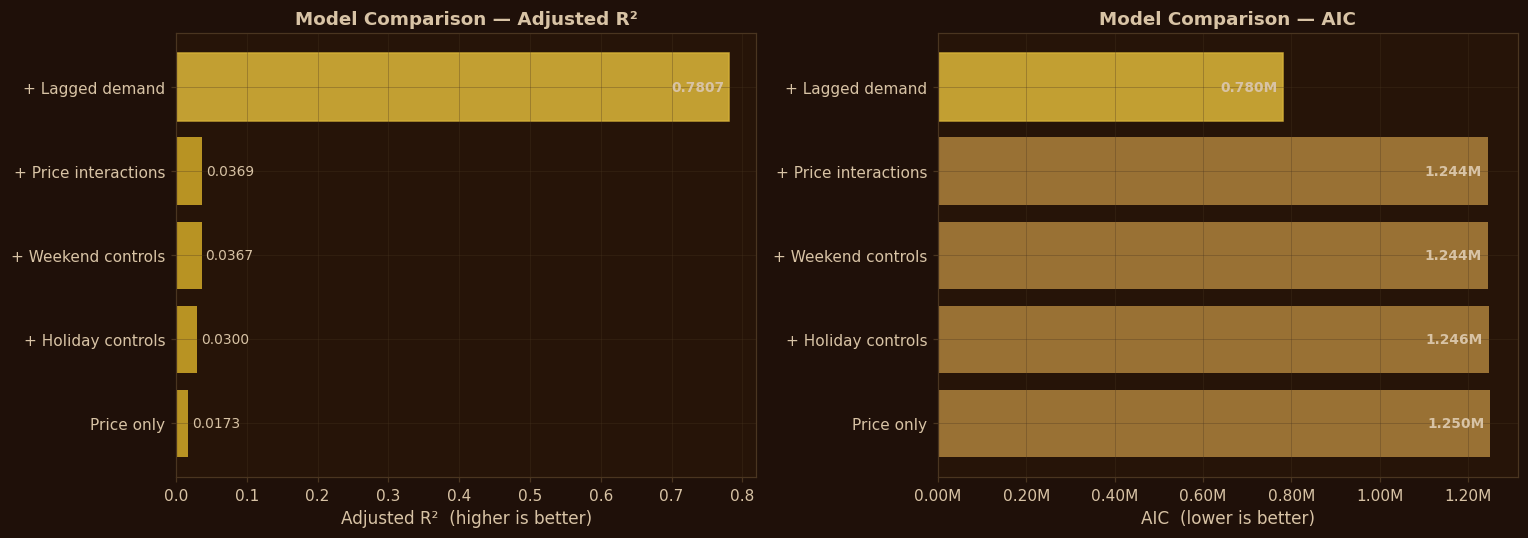

In [73]:
cmp = agg.sort_values(['County', 'Category Name', 'Year', 'Month']).copy()
cmp['lag_log_demand'] = cmp.groupby(['County', 'Category Name'])['log_demand'].shift(1)
cmp = cmp.dropna(subset=['log_demand', 'log_price', 'lag_log_demand'])
cmp['price_x_holiday'] = cmp['log_price'] * cmp['Is_Holiday']
cmp['price_x_weekend'] = cmp['log_price'] * cmp['Weekend_Count']
y_cmp = cmp['log_demand']

def fit_cmp(cols, label):
    res = sm.OLS(y_cmp, sm.add_constant(cmp[cols].astype(float))).fit()
    return {'Model': label, 'R2': round(res.rsquared, 4),
            'Adj. R2': round(res.rsquared_adj, 4),
            'AIC': round(res.aic, 1), 'BIC': round(res.bic, 1), 'N': int(res.nobs)}

comp_df = pd.DataFrame([
    fit_cmp(['log_price'],                                                    'Price only'),
    fit_cmp(['log_price', 'Is_Holiday'],                                      '+ Holiday controls'),
    fit_cmp(['log_price', 'Is_Holiday', 'Weekend_Count'],                     '+ Weekend controls'),
    fit_cmp(['log_price', 'Is_Holiday', 'Weekend_Count',
             'price_x_holiday', 'price_x_weekend'],                           '+ Price interactions'),
    fit_cmp(['log_price', 'Is_Holiday', 'Weekend_Count', 'lag_log_demand'],   '+ Lagged demand'),
])
print(comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
apply_dark_style(fig, axes)

# Adj R2 panel
bar_r2 = axes[0].barh(comp_df['Model'], comp_df['Adj. R2'], color=GOLD_MID, alpha=0.90)
bar_r2[-1].set_color(GOLD_BRIGHT)
axes[0].set_xlabel('Adjusted R²  (higher is better)', fontsize=11, color=TEXT_CREAM)
axes[0].set_title('Model Comparison — Adjusted R²', fontsize=12, fontweight='bold', color=TEXT_CREAM)
for i, v in enumerate(comp_df['Adj. R2']):
    if v > 0.1:
        axes[0].text(v - 0.005, i, f'{v:.4f}', va='center', ha='right', fontsize=9,
                     color=TEXT_CREAM, fontweight='bold')
    else:
        axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', ha='left', fontsize=9, color=TEXT_CREAM)

# AIC panel
aic_max = comp_df['AIC'].max()
bar_aic = axes[1].barh(comp_df['Model'], comp_df['AIC'], color=GOLD_WARM, alpha=0.90)
bar_aic[-1].set_color(GOLD_BRIGHT)
axes[1].set_xlabel('AIC  (lower is better)', fontsize=11, color=TEXT_CREAM)
axes[1].set_title('Model Comparison — AIC', fontsize=12, fontweight='bold', color=TEXT_CREAM)
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
for i, v in enumerate(comp_df['AIC']):
    axes[1].text(v - aic_max * 0.01, i, f'{v/1e6:.3f}M', va='center', ha='right',
                 fontsize=9, color=TEXT_CREAM, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/11_model_comparison_aic_r2.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


## Full Fixed-Effects Model Comparison Table

In [74]:
pf.etable(
    [m0, m1, m2, m3, m7, m10, m11],
    labels={
        'liters_per_adult': 'Liters/Adult',
        'log_liters_pa': 'log(Liters/Adult)',
        'avg_price_liter': 'Price/Liter ($)',
        'log_price': 'log(Price/Liter)',
        'log_price_sq': 'log(Price)^2',
        'holiday_days': 'Holiday Days',
        'log_price:holiday_days': 'log(Price) x Holiday',
        'log_liters_pa_lag': 'log(Demand t-1)',
        'log_price_lag': 'log(Price t-1)',
    },
    model_heads=['M0\nLinear', 'M1\nSemi-log', 'M2\nLog-log',
                 'M3\nQuadratic', 'M7\nHoliday',
                 'M10\nLag Demand', 'M11\nLag Price'],
    coef_fmt='b (se)',
    keep=['avg_price_liter', 'log_price', 'log_price_sq', 'holiday_days',
          'log_price:holiday_days',
          'log_liters_pa_lag', 'log_price_lag']
)

GT(_tbl_data=   __index_level_0__                __index_level_1__                     0  \
0               coef                  Price/Liter ($)   0.000006 (0.000206)   
1               coef                 log(Price/Liter)                         
2               coef                     log(Price)^2                         
3               coef  log(Price/Liter) × Holiday Days                         
4               coef                   log(Price t-1)                         
5               coef                     Holiday Days  -0.000456 (0.000318)   
6               coef                  log(Demand t-1)                         
7                 fe                        category                      x   
8                 fe                           month                      x   
9                 fe                             year                     x   
10                fe                          county                      x   
11             stats                     Observations                49,238   
12             stats                               R²                 0.727   

                 1               2               3               4  \
0   -0.029 (0.004)                                                   
1                   -0.461 (0.064)   0.708 (0.469)  -0.478 (0.064)   
2                                   -0.217 (0.089)                   
3                                                    0.033 (0.011)   
4                                                                    
5   -0.032 (0.006)  -0.032 (0.006)  -0.032 (0.006)   -0.12 (0.029)   
6                                                                    
7                x               x               x               x   
8                x               x               x               x   
9                x               x               x               x   
10               x               x               x               x   
11          49,238          49,238          49,238          49,238   
12            0.87            0.87            0.87            0.87   

                 5               6  
0                                   
1   -0.359 (0.044)  -0.445 (0.054)  
2                                   
3                                   
4                   -0.044 (0.039)  
5   -0.013 (0.007)  -0.028 (0.007)  
6    0.455 (0.017)                  
7                x               x  
8                x               x  
9                x               x  
10               x               x  
11          48,347          48,347  
12           0.897            0.87  , _body=<great_tables._gt_data.Body object at 0x373ce6690>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='4', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='5', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None), ColInfo(var='6', type=<ColInfoTypeEnum.default: 1>, column_label='(7)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x30f1e5010>, _spanners=Spanners([SpannerInfo(spanner_id='Liters/Adult', spanner_level=2, spanner_label='Liters/Adult', spanner_units=None, spanner_pattern=None, va

---
# 12. Holdout Validation (2012-2015 Train / 2016-2017 Test)

Validates the best model's predictive accuracy on an unseen time period.

Train years: 2012-2015  (228,815 obs)
Test  years: 2016-2017  (84,361 obs)
Train RMSE: 0.8405
Test  RMSE: 0.8441
R2  (test): 0.7534


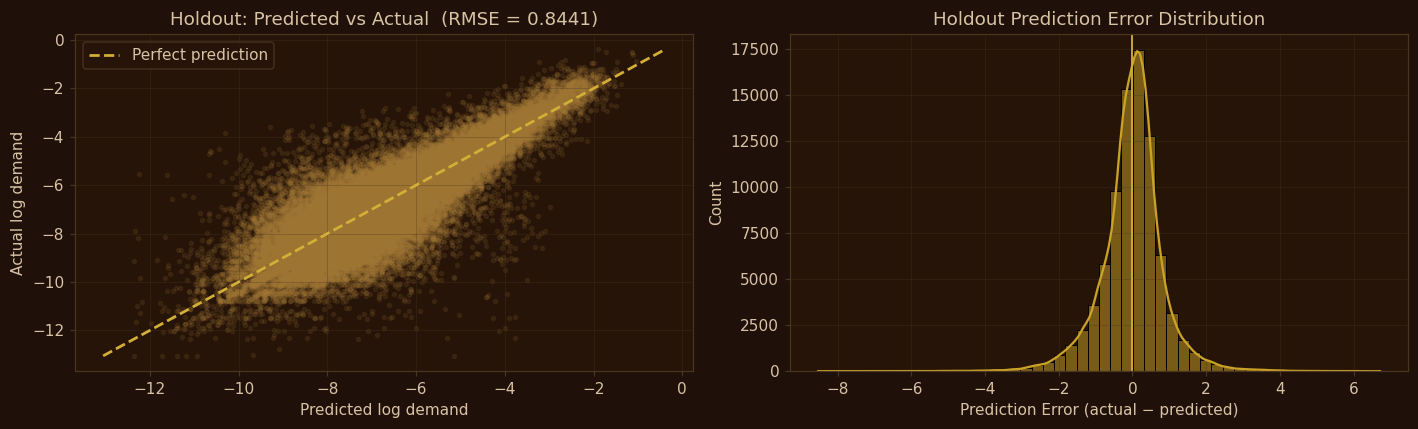

In [75]:
val = agg.sort_values(['County', 'Category Name', 'Year', 'Month']).copy()
val['lag_log_demand'] = val.groupby(['County', 'Category Name'])['log_demand'].shift(1)
val = val.dropna(subset=['log_demand', 'log_price', 'lag_log_demand'])

train = val[val['Year'] <= 2015]
test  = val[val['Year'] >= 2016]

feats = ['log_price', 'Is_Holiday', 'Weekend_Count', 'lag_log_demand']
X_tr  = sm.add_constant(train[feats].astype(float))
X_te  = sm.add_constant(test[feats].astype(float)).reindex(columns=X_tr.columns, fill_value=0)

model_val = sm.OLS(train['log_demand'], X_tr).fit()
y_pred    = model_val.predict(X_te)
y_true    = test['log_demand']

rmse_train = np.sqrt(mean_squared_error(train['log_demand'], model_val.fittedvalues))
rmse_test  = np.sqrt(mean_squared_error(y_true, y_pred))
r2_test    = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2)

print(f'Train years: 2012-2015  ({len(train):,} obs)')
print(f'Test  years: 2016-2017  ({len(test):,} obs)')
print(f'Train RMSE: {rmse_train:.4f}')
print(f'Test  RMSE: {rmse_test:.4f}')
print(f'R2  (test): {r2_test:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
apply_dark_style(fig, axes)

axes[0].scatter(y_pred, y_true, alpha=0.12, s=7, color=GOLD_WARM)
mn = min(y_pred.min(), y_true.min())
mx = max(y_pred.max(), y_true.max())
axes[0].plot([mn, mx], [mn, mx], color=GOLD_BRIGHT, linewidth=1.8,
             linestyle='--', label='Perfect prediction')
axes[0].set_xlabel('Predicted log demand', color=TEXT_CREAM)
axes[0].set_ylabel('Actual log demand', color=TEXT_CREAM)
axes[0].set_title(f'Holdout: Predicted vs Actual  (RMSE = {rmse_test:.4f})', color=TEXT_CREAM)
axes[0].legend(facecolor=PANEL_BG, edgecolor=AXIS_COLOR, labelcolor=TEXT_CREAM)

resid_test = y_true.values - y_pred.values
sns.histplot(resid_test, bins=50, kde=True, ax=axes[1],
             color=GOLD_MID, line_kws={'color': GOLD_BRIGHT, 'lw': 1.5})
axes[1].axvline(0, color=GOLD_BRIGHT, linewidth=1.2)
axes[1].set_xlabel('Prediction Error (actual − predicted)', color=TEXT_CREAM)
axes[1].set_title('Holdout Prediction Error Distribution', color=TEXT_CREAM)

plt.tight_layout()
plt.savefig('figures/12_holdout_validation.png', bbox_inches='tight', dpi=150, facecolor=BG)
plt.show()


---
# 13. Conclusions and Managerial Implications

## Summary of Findings

| Research Question | Model | Finding |
|---|---|---|
| Is overall demand elastic or inelastic? | M2 | **Inelastic (e approx -0.46)** - market is not very price sensitive overall |
| Best functional form? | M0-M3 | **Log-log (M2)** - linear fails; quadratic confirms non-constant elasticity |
| Most price-sensitive broad category? | M4 | **Whiskey (e approx -1.30)** - only consolidated category crossing unit elastic |
| Most price-sensitive granular items? | M4b | **Specialty schnapps and flavored spirits (e < -2)** - invisible in 8-category view |
| Urban vs rural differences? | M5 | **Urban consumers NOT significantly price sensitive (p approx 0.75)**; rural and suburban drive all aggregate elasticity |
| Which counties to target? | M5b/M5c | **Mills, Fremont, Henry** counties most price-sensitive; cross-referencing with category identifies highest-ROI promotion targets |
| Less sensitive on holidays? | M7 | **Yes** - elasticity softens from -0.48 (no holidays) to -0.15 (10 holiday days) |
| Seasonal elasticity cycle? | M8 | **Yes** - January most elastic; October least elastic |
| Stability over time? | M9 | **No significant trend** - elasticity stable 2012-2017 |
| Habit persistence? | M10 | **Strong** (lag b approx 0.45***). Long-run e approx 1.8x larger than short-run |
| Lagged price effects? | M11 | **No** - price effects are immediate; no echo month-over-month |
| Vodka-Whiskey substitution? | M12 | **Yes** - cross-price e approx +0.30-0.41***; coordinated pricing required |
| Out-of-sample accuracy? | Holdout | **Test R2 approx 0.75, RMSE approx 0.85** on 2016-2017 |

---

## Managerial Recommendations

**1. Price Whiskey carefully - it is the only revenue-at-risk broad category.**
Whiskey demand is elastic, meaning a price increase loses more in volume than it gains in margin. All other consolidated categories can absorb moderate price increases.

**2. Do not discount during the holiday season - hold prices instead.**
Holiday months are when consumers are least price-sensitive. Discounting in Nov-Dec wastes margin. Save promotions for Jan-Mar.

**3. Build separate pricing rules for rural vs. urban counties.**
Urban demand is statistically insensitive to price. Rural and suburban counties drive the entire aggregate elasticity.

**4. Use the county x category heatmap (M5c) to prioritize promotion budgets.**
Cells showing the most negative elasticity are the highest-return targets for promotions.

**5. Plan for long-run price effects - they are ~1.8x larger than month-1 data shows.**
The habit persistence result (M10) means demand keeps adjusting for months after a price change.

**6. Coordinate Vodka and Whiskey pricing jointly.**
Cross-price elasticity of ~0.3-0.4 between the two largest categories means independent pricing leaves revenue on the table.

**7. Watch specialty schnapps and flavored spirits for volume-sensitive promotions.**
The granular analysis (M4b) reveals niche categories with elasticities exceeding -4. These items respond dramatically to price promotions.

---

*Analysis conducted using Python with `pyfixest` for panel fixed-effects models and `statsmodels` for granular OLS and holdout validation. Two panel datasets: (1) ~49,000 observations across 99 counties, 8 categories, 56 year-months with county + category + month + year fixed effects; (2) granular 130-category panel for deep-dive OLS. Standard errors clustered by county.*